# Trial-by-Trial Neural Dynamics — BLT Protocol

Pipeline:
1. Load BLT epochs (subject 5, BLT channel group: T7, T8, TP7, TP8)
2. Baseline correction (−200 ms to 0 ms, mean subtraction)
3. ERP visualization per channel
4. Feature extraction per trial per channel:
   - Mean amplitude 0–100 ms
   - Mean amplitude 100–200 ms
   - Mean amplitude 200–400 ms
   - **Peak positive amplitude** in 0–300 ms (max µV in window)
   - **Peak latency** in 0–300 ms (time of that maximum, ms)
5. Trial-by-trial plots with rolling mean


In [11]:
#! pip install mne

#nothing

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from utils import load_eeg_data, FREQ_BANDS

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## 1. Load Data

In [13]:
CONDITION  = "BLT"
SUBJECT_ID = 5
CHANNELS   = "BLT"   # T7, T8, TP7, TP8
FREQ_BANDS = "beta_gamma"

# Data path (resolved inside utils): <project>/dataset/BLT/binepochs filtered ICArej BLTAvgBOS5.set
epochs = load_eeg_data(CONDITION, SUBJECT_ID, channels=CHANNELS)

data   = epochs.get_data()   # (n_trials, n_channels, n_times)  — in Volts (MNE default)
data   = data * 1e6           # convert to µV
times  = epochs.times        # in seconds
ch_names = epochs.ch_names
sfreq  = epochs.info['sfreq']

n_trials, n_channels, n_times = data.shape

print(f"Condition     : {CONDITION}  |  Subject: {SUBJECT_ID}")
print(f"Channels      : {ch_names}")
print(f"Trials        : {n_trials}")
print(f"Time window   : {times[0]*1000:.0f} ms  to  {times[-1]*1000:.0f} ms")
print(f"Sampling rate : {sfreq} Hz")
print(f"Data shape    : {data.shape}  (trials × channels × times)")

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Condition     : BLT  |  Subject: 5
Channels      : ['C3', 'C4', 'CP1', 'CP2']
Trials        : 60
Time window   : -500 ms  to  2998 ms
Sampling rate : 512.0 Hz
Data shape    : (60, 4, 1792)  (trials × channels × times)


/Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/utils.py:128: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


## 2. Baseline Correction  (−200 ms to 0 ms, mean subtraction)

In [14]:
BASELINE_TMIN = -0.200   # seconds
BASELINE_TMAX =  0.000
ROLLING_WINDOW = 5       # trials in the moving average

baseline_mask = (times >= BASELINE_TMIN) & (times <= BASELINE_TMAX)
print(f"Baseline samples : {baseline_mask.sum()}  "
      f"({times[baseline_mask][0]*1000:.0f} ms to {times[baseline_mask][-1]*1000:.0f} ms)")

# Mean per trial × channel over the baseline window
baseline_mean = data[:, :, baseline_mask].mean(axis=-1, keepdims=True)  # (trials, channels, 1)

# Subtract from every time point
data_bc = data - baseline_mean   # (trials, channels, times)

print("Baseline correction done — data_bc shape:", data_bc.shape)

Baseline samples : 103  (-199 ms to 0 ms)
Baseline correction done — data_bc shape: (60, 4, 1792)


## 3. ERP Visualization per Channel

Average across all trials to reveal the event-related potential.

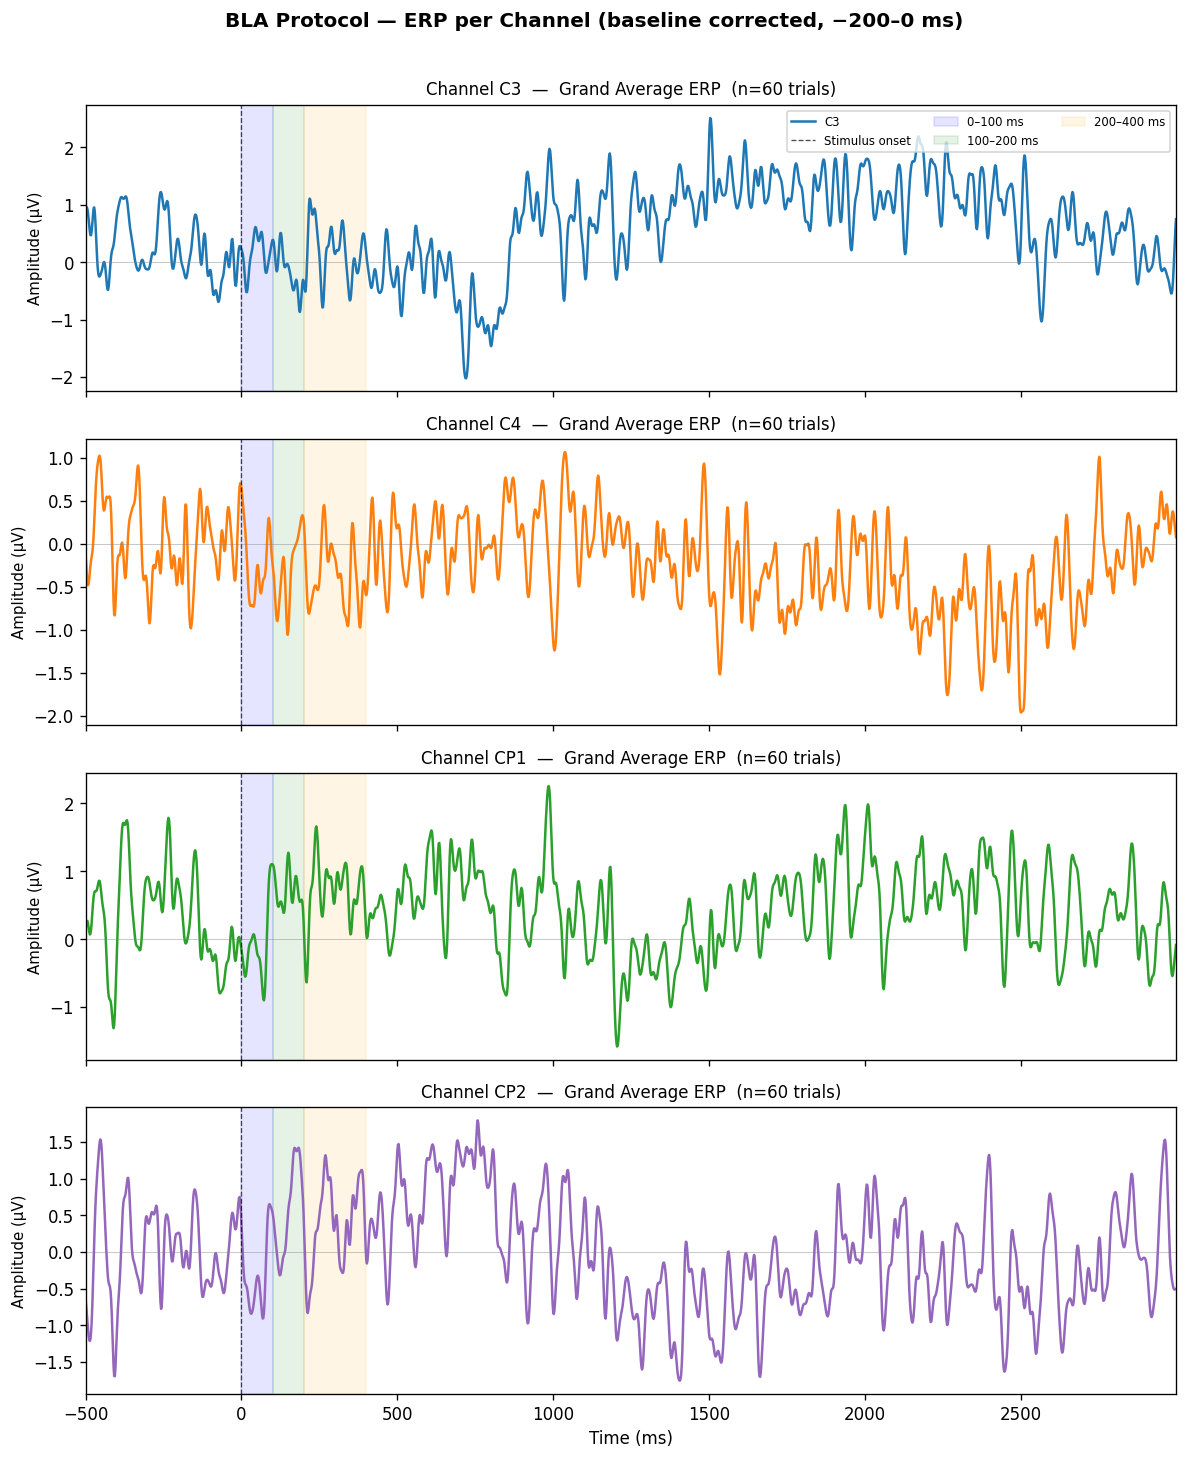

Figure saved: erp_BLA_per_channel.png


In [6]:
erp = data_bc.mean(axis=0)   # (n_channels, n_times)  — grand average ERP
times_ms = times * 1000      # convert to ms for plotting

fig, axes = plt.subplots(n_channels, 1, figsize=(10, 3 * n_channels), sharex=True)
if n_channels == 1:
    axes = [axes]

colors = plt.cm.tab10(np.linspace(0, 0.4, n_channels))

for i, (ax, ch) in enumerate(zip(axes, ch_names)):
    ax.plot(times_ms, erp[i], color=colors[i], linewidth=1.5, label=ch)
    ax.axvline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.7, label='Stimulus onset')
    ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

    # Shade feature windows
    ax.axvspan(0, 100,   alpha=0.10, color='blue',   label='0–100 ms')
    ax.axvspan(100, 200, alpha=0.10, color='green',  label='100–200 ms')
    ax.axvspan(200, 400, alpha=0.10, color='orange', label='200–400 ms')

    ax.set_ylabel('Amplitude (µV)', fontsize=9)
    ax.set_title(f'Channel {ch}  —  Grand Average ERP  (n={n_trials} trials)', fontsize=10)
    ax.set_xlim(times_ms[0], times_ms[-1])

    if i == 0:
        ax.legend(loc='upper right', fontsize=7, ncol=3)

axes[-1].set_xlabel('Time (ms)', fontsize=10)
fig.suptitle(f'BLA Protocol — ERP per Channel (baseline corrected, −200–0 ms)',
             fontsize=12, fontweight='bold', y=1.01)
fig.tight_layout()
plt.savefig('erp_BLA_per_channel.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: erp_BLA_per_channel.png")

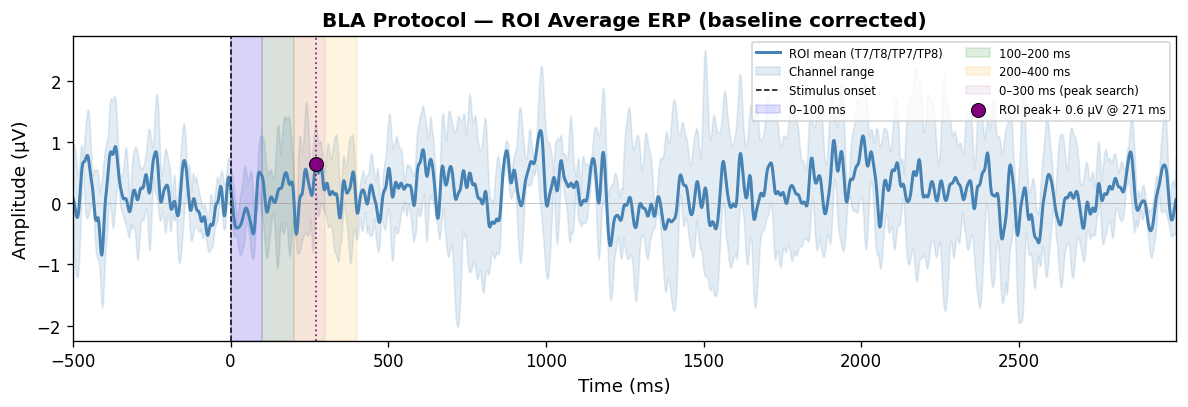

In [7]:
# --- ROI average ERP (mean across all BLA channels) ---
erp_roi = erp.mean(axis=0)   # (n_times,)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(times_ms, erp_roi, color='steelblue', linewidth=1.8, label='ROI mean (T7/T8/TP7/TP8)')
ax.fill_between(times_ms, erp.min(axis=0), erp.max(axis=0),
                color='steelblue', alpha=0.15, label='Channel range')
ax.axvline(0, color='k', linestyle='--', linewidth=0.9, label='Stimulus onset')
ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvspan(0, 100,   alpha=0.12, color='blue',   label='0–100 ms')
ax.axvspan(100, 200, alpha=0.12, color='green',  label='100–200 ms')
ax.axvspan(200, 400, alpha=0.12, color='orange', label='200–400 ms')
ax.axvspan(0, 300, alpha=0.06, color='purple', label='0–300 ms (peak search)')

# Grand-average ROI: peak positive & latency in 0–300 ms (same definition as trial features)
_pk_mask = (times_ms >= 0) & (times_ms <= 300)
_t = times_ms[_pk_mask]
_v = erp_roi[_pk_mask]
_i = int(np.argmax(_v))
_lat, _amp = _t[_i], _v[_i]
ax.scatter([_lat], [_amp], color='purple', s=70, zorder=6, edgecolors='k', linewidths=0.6,
           label=f'ROI peak+ {_amp:.1f} µV @ {_lat:.0f} ms')
ax.axvline(_lat, color='purple', linestyle=':', linewidth=1.1, alpha=0.85)

ax.set_xlabel('Time (ms)', fontsize=11)
ax.set_ylabel('Amplitude (µV)', fontsize=11)
ax.set_title('BLA Protocol — ROI Average ERP (baseline corrected)', fontsize=12, fontweight='bold')
ax.set_xlim(times_ms[0], times_ms[-1])
ax.legend(loc='upper right', fontsize=7, ncol=2)
fig.tight_layout()
plt.savefig('erp_BLA_roi_average.png', bbox_inches='tight', dpi=150)
plt.show()


## 4. Feature Extraction per Trial × Channel

For each trial and each channel we compute:

**Mean amplitude** (baseline-corrected) in three post-stimulus windows:
- **0–100 ms** (early sensory)
- **100–200 ms** (N1/P2 range)
- **200–400 ms** (later processing)

**Peak metrics in 0–300 ms:**
- **Peak positive amplitude**: maximum baseline-corrected voltage in that window (µV) — local positive peak.
- **Peak latency**: time of that maximum relative to stimulus onset (ms).


In [32]:
# Time masks for each feature window
mask_0_100   = (times >= 0.000) & (times <= 0.100)
mask_100_200 = (times >= 0.100) & (times <= 0.200)
mask_200_400 = (times >= 0.200) & (times <= 0.400)
mask_0_300   = (times >= 0.000) & (times <= 0.300)   # peak search window

print("Window sample counts:")
print(f"  0–100 ms  : {mask_0_100.sum()} samples")
print(f"  100–200 ms: {mask_100_200.sum()} samples")
print(f"  200–400 ms: {mask_200_400.sum()} samples")
print(f"  0–300 ms  : {mask_0_300.sum()} samples (peak amp / latency)")

# Feature arrays: (n_trials, n_channels) — mean amplitude windows
feat_0_100   = data_bc[:, :, mask_0_100].mean(axis=-1)
feat_100_200 = data_bc[:, :, mask_100_200].mean(axis=-1)
feat_200_400 = data_bc[:, :, mask_200_400].mean(axis=-1)

# Peak positive amplitude & latency in 0–300 ms (per trial × channel)
times_0_300 = times[mask_0_300]
win_0_300 = data_bc[:, :, mask_0_300]   # (trials, ch, samples)
peak_ix = win_0_300.argmax(axis=-1)   # index of maximum µV in window
feat_peak_amp_0_300 = np.take_along_axis(win_0_300, peak_ix[..., None], axis=-1).squeeze(-1)
feat_peak_lat_0_300_ms = times_0_300[peak_ix] * 1000.0   # seconds → ms

# ROI average across channels: (n_trials,)
roi_0_100   = feat_0_100.mean(axis=1)
roi_100_200 = feat_100_200.mean(axis=1)
roi_200_400 = feat_200_400.mean(axis=1)
roi_peak_amp_0_300 = feat_peak_amp_0_300.mean(axis=1)
roi_peak_lat_0_300 = feat_peak_lat_0_300_ms.mean(axis=1)

trial_idx = np.arange(1, n_trials + 1)

# Collect into a DataFrame for easy inspection
rows = []
for t in range(n_trials):
    for c, ch in enumerate(ch_names):
        rows.append({
            'trial': t + 1,
            'channel': ch,
            'amp_0_100':   feat_0_100[t, c],
            'amp_100_200': feat_100_200[t, c],
            'amp_200_400': feat_200_400[t, c],
            'peak_pos_amp_0_300_uv': feat_peak_amp_0_300[t, c],
            'peak_lat_0_300_ms':     feat_peak_lat_0_300_ms[t, c],
        })
features_df = pd.DataFrame(rows)
print("\nFeature DataFrame (first 8 rows):")
features_df.head(8)


Window sample counts:
  0–100 ms  : 52 samples
  100–200 ms: 51 samples
  200–400 ms: 102 samples
  0–300 ms  : 154 samples (peak amp / latency)

Feature DataFrame (first 8 rows):


,trial,channel,amp_0_100,amp_100_200,amp_200_400,peak_pos_amp_0_300_uv,peak_lat_0_300_ms
0,1,T7,5.609618,4.393832,-0.608417,19.245318,101.562500
1,1,T8,2.234826,0.482644,-0.955328,14.463423,246.093750
2,1,TP7,5.822789,5.543579,-0.544146,26.753023,101.562500
3,1,TP8,2.812455,0.908756,-1.692234,14.704839,246.093750
4,2,T7,-2.123390,-4.686120,-7.726102,3.780155,41.015625
5,2,T8,1.773534,1.665672,-6.738448,13.890123,175.781250
6,2,TP7,-1.716981,-4.199324,-8.407957,6.726034,97.656250
7,2,TP8,3.734365,4.085105,-7.245894,14.177499,177.734375


In [33]:
# Basic statistics across trials (ROI average)
print("ROI-averaged feature statistics across trials:")
summary = pd.DataFrame({
    '0–100 ms':   roi_0_100,
    '100–200 ms': roi_100_200,
    '200–400 ms': roi_200_400,
    'Peak+ 0–300 µV': roi_peak_amp_0_300,
    'Peak lat 0–300 ms': roi_peak_lat_0_300,
})
summary.describe().round(4)


ROI-averaged feature statistics across trials:


,0–100 ms,100–200 ms,200–400 ms,Peak+ 0–300 µV,Peak lat 0–300 ms
count,60.0000,60.0000,60.0000,60.0000,60.0000
mean,1.7242,-0.8289,0.4251,12.2372,118.4977
std,3.0183,3.6011,3.6763,3.9271,59.1244
min,-4.8231,-8.1690,-7.6020,4.4974,11.7188
25%,0.3527,-2.5712,-2.0540,9.0962,75.5615
50%,1.8257,-0.9880,0.3722,11.5942,104.7363
75%,3.5422,2.3458,2.7674,14.7568,168.9453
max,8.1716,6.7035,9.6227,22.8294,259.7656


## 5. Trial-by-Trial Dynamics

Plot each feature against trial index and overlay a rolling mean to reveal learning-related trends.

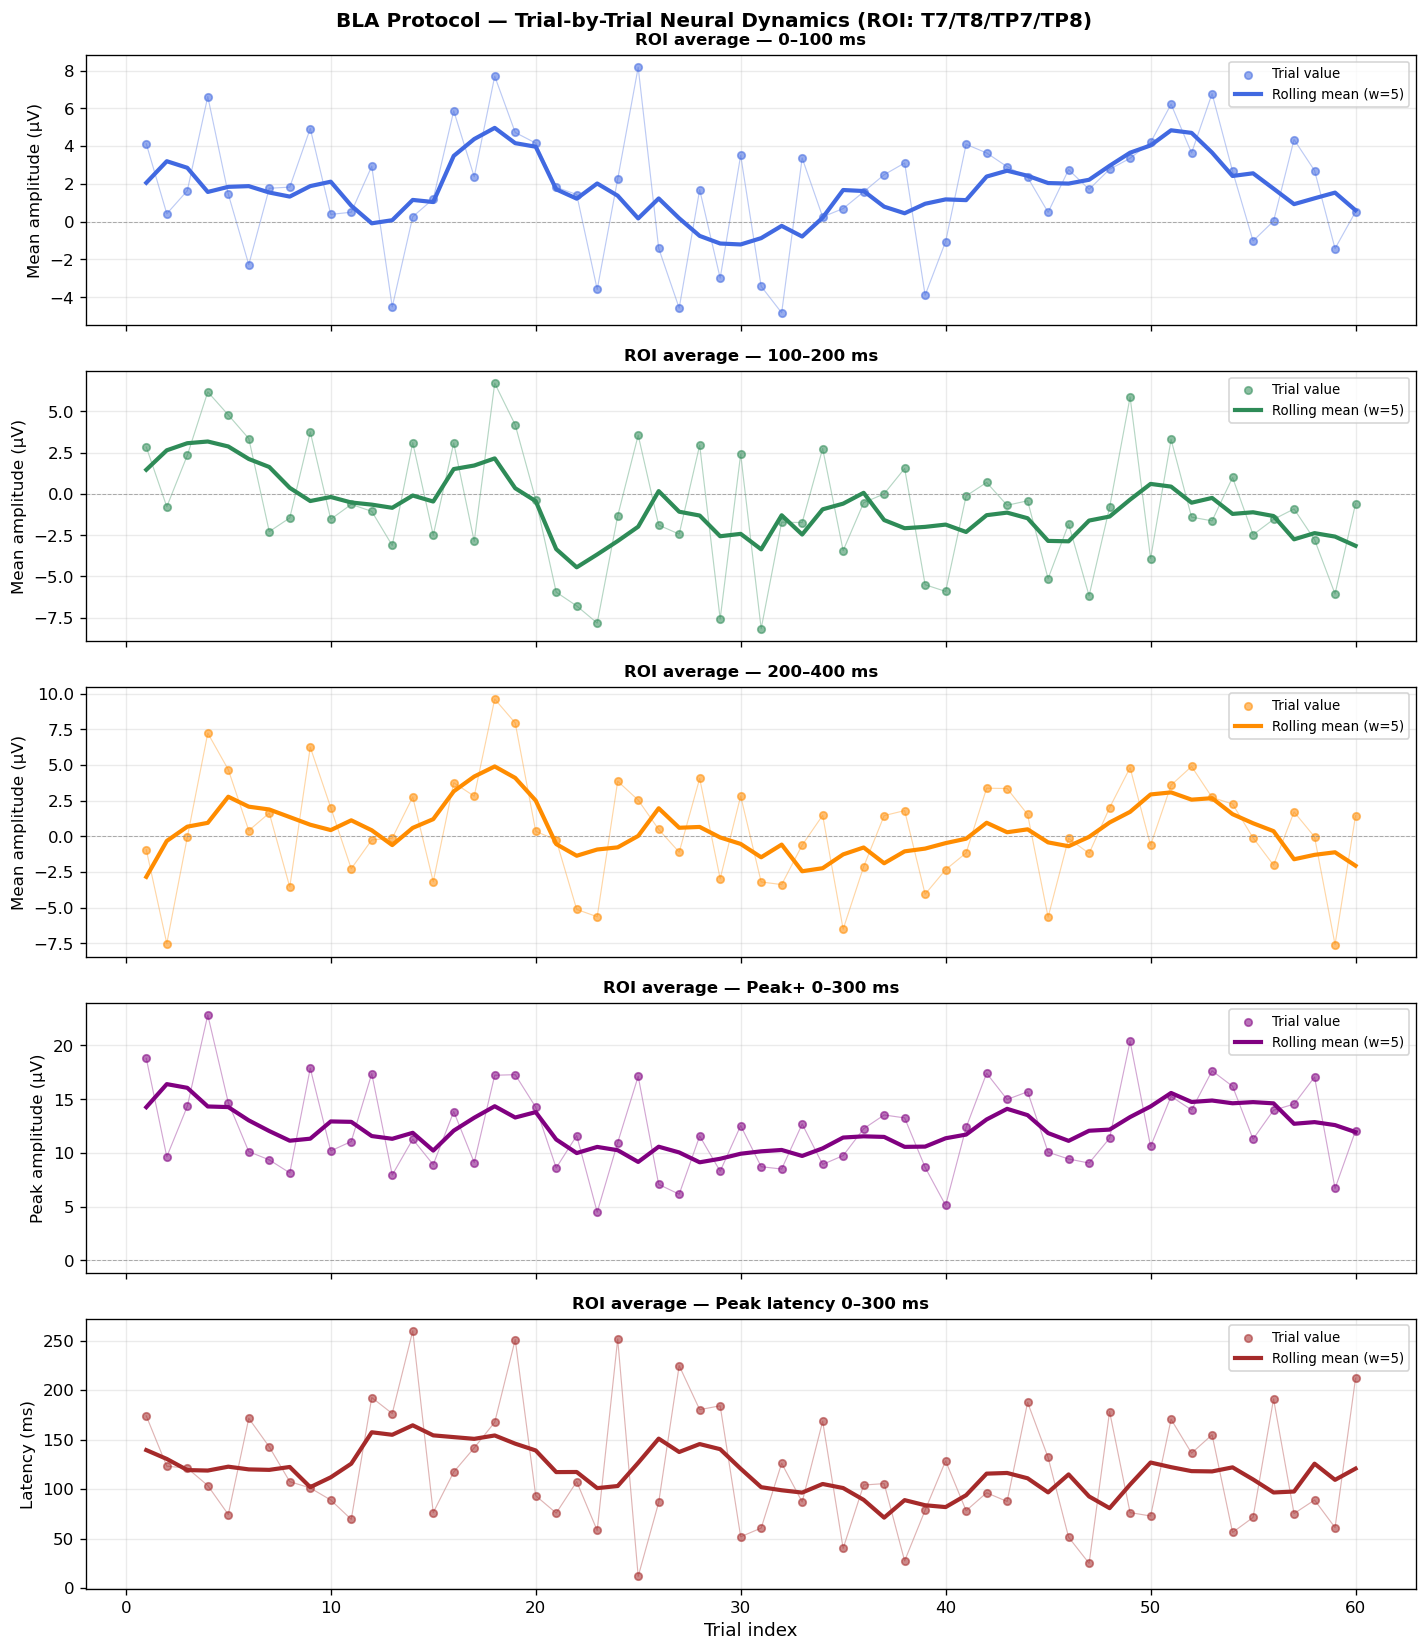

Figure saved: trial_dynamics_BLA_roi.png


In [34]:
ROLLING_WINDOW = 5   # trials in the moving average

windows = [
    ('0–100 ms',   roi_0_100,   'royalblue',   'Mean amplitude (µV)'),
    ('100–200 ms', roi_100_200, 'seagreen',    'Mean amplitude (µV)'),
    ('200–400 ms', roi_200_400, 'darkorange',  'Mean amplitude (µV)'),
    ('Peak+ 0–300 ms', roi_peak_amp_0_300, 'purple', 'Peak amplitude (µV)'),
    ('Peak latency 0–300 ms', roi_peak_lat_0_300, 'brown', 'Latency (ms)'),
]

fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

for ax, (label, values, color, ylab) in zip(axes, windows):
    ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Trial value')
    ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

    s = pd.Series(values)
    rolling = s.rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
    ax.plot(trial_idx, rolling, color=color, linewidth=2.5, zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})')

    if not label.startswith('Peak latency'):
        ax.axhline(0, color='gray', linewidth=0.6, linestyle='--', alpha=0.6)
    ax.set_ylabel(ylab, fontsize=10)
    ax.set_title(f'ROI average — {label}', fontsize=10, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Trial index', fontsize=11)
fig.suptitle(f'BLA Protocol — Trial-by-Trial Neural Dynamics (ROI: T7/T8/TP7/TP8)',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('trial_dynamics_BLA_roi.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: trial_dynamics_BLA_roi.png")


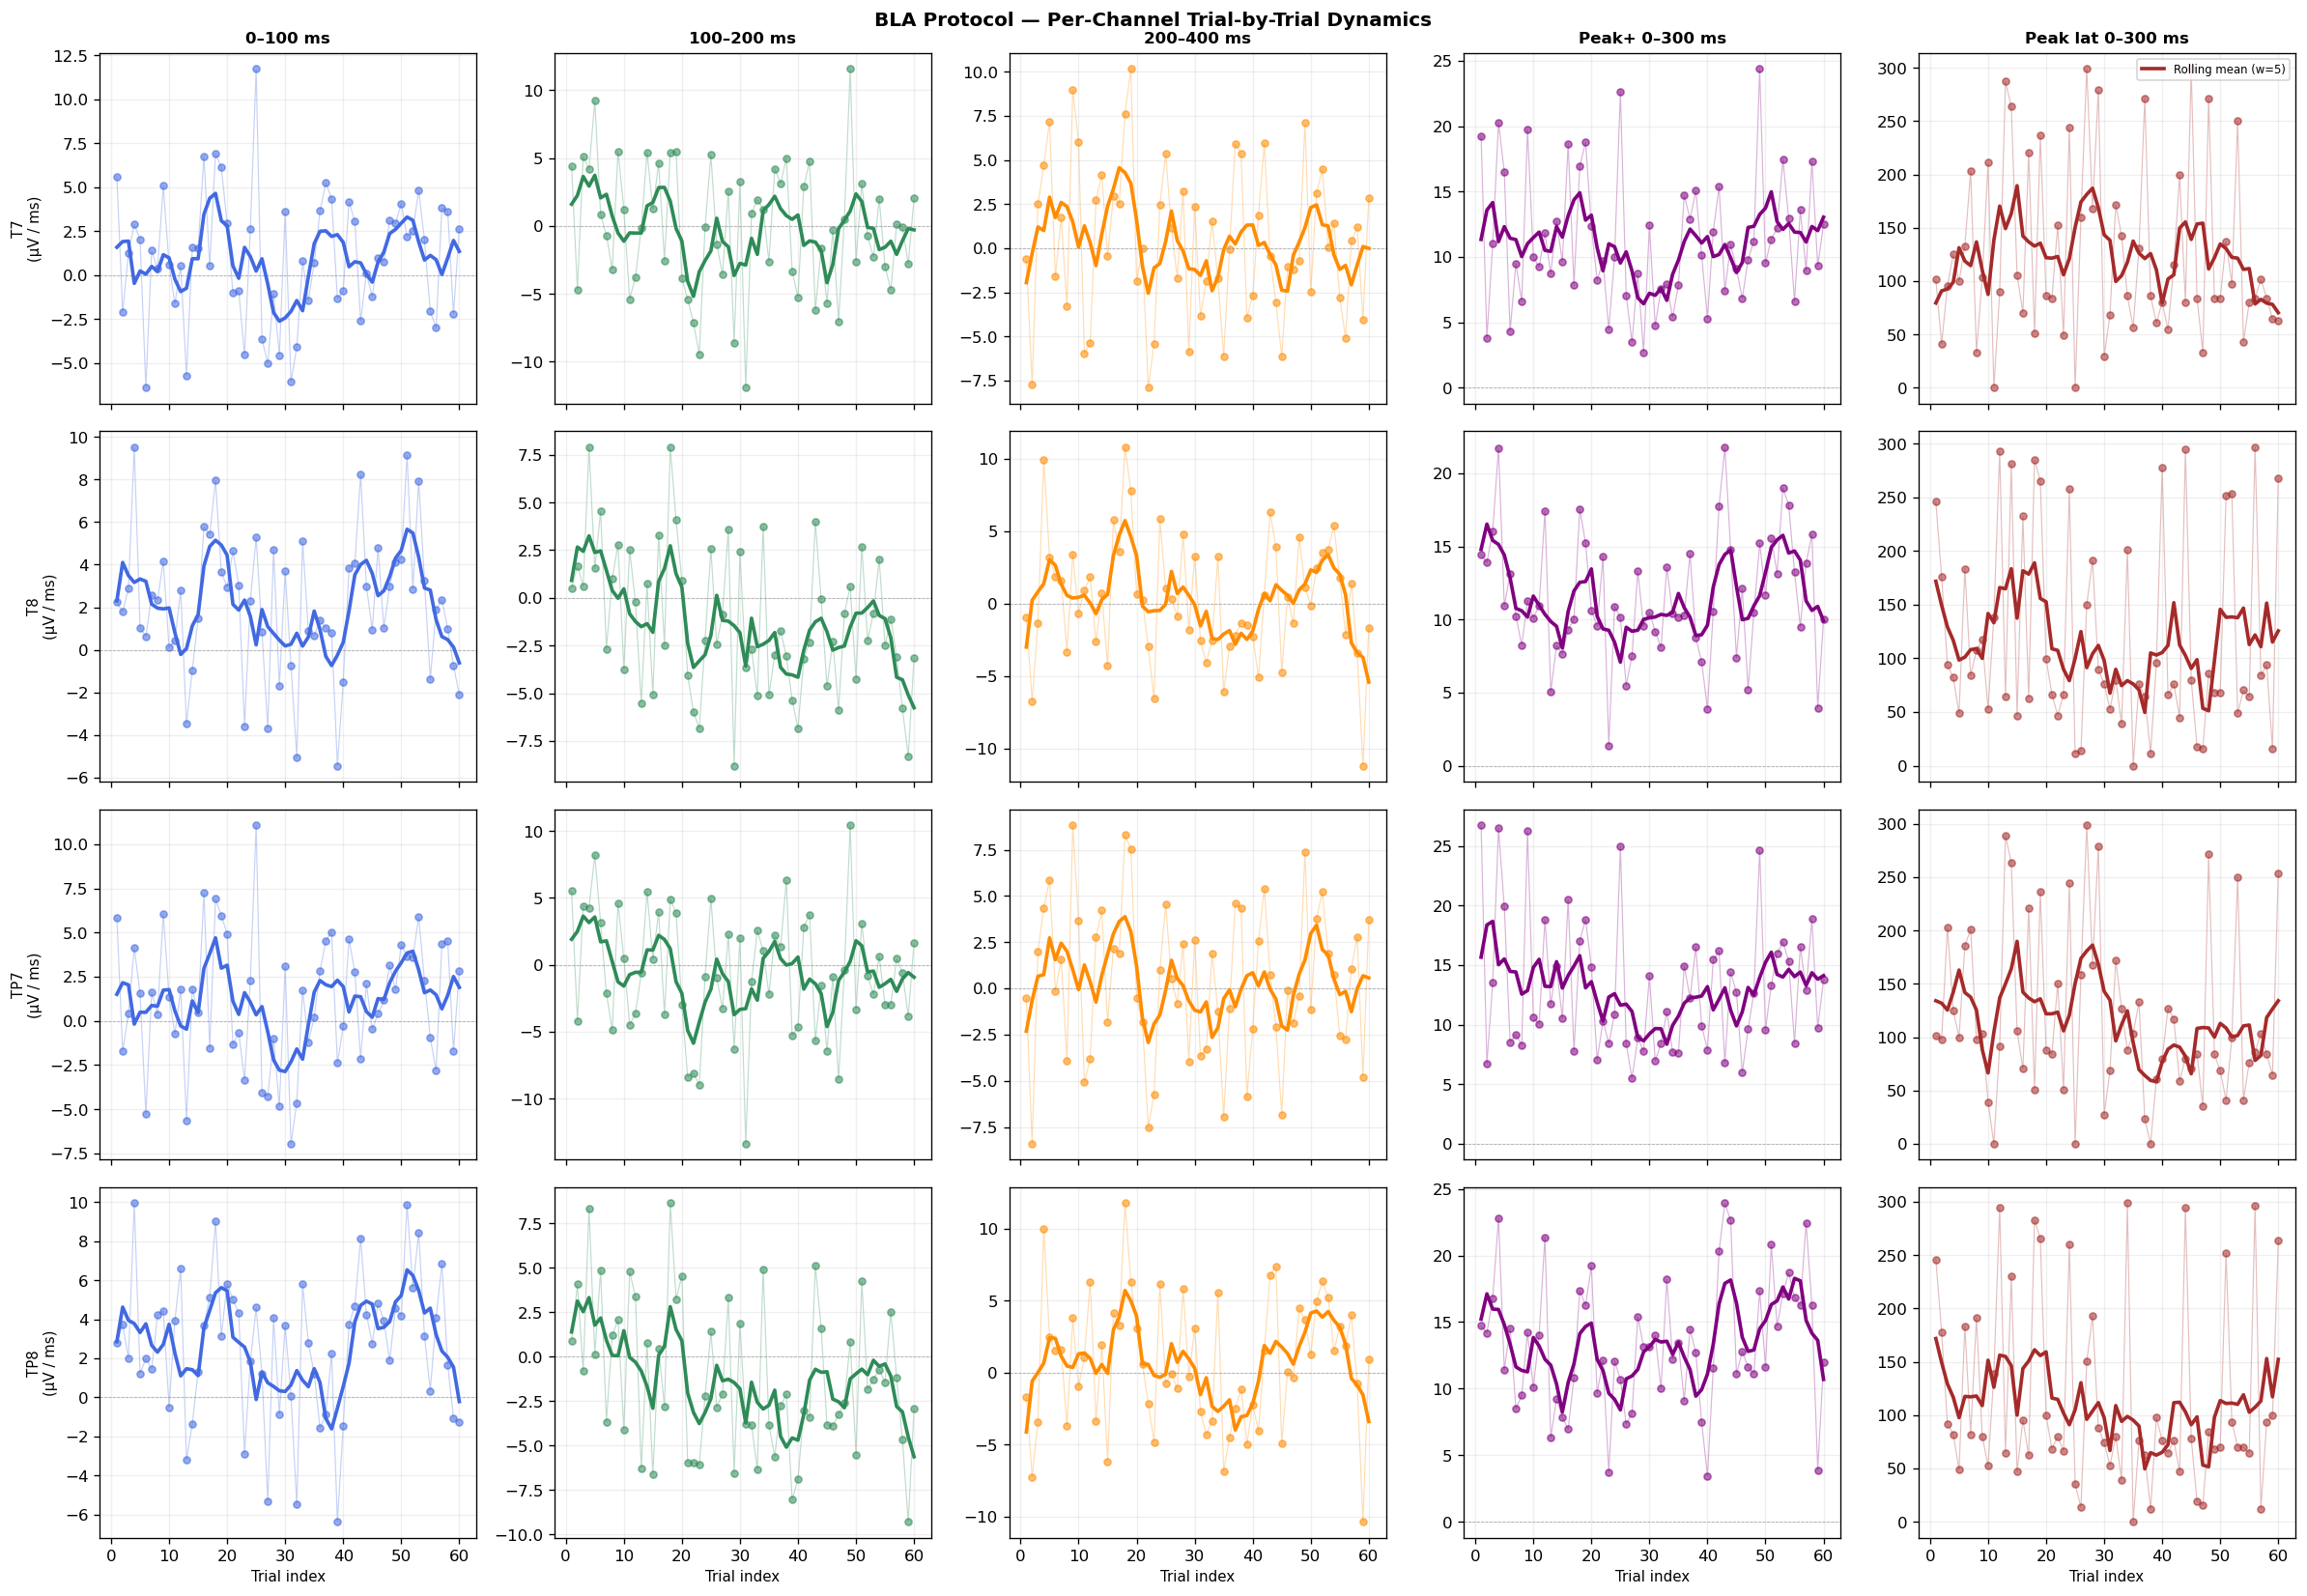

Figure saved: trial_dynamics_BLA_per_channel.png


In [35]:
# --- Per-channel trial-by-trial dynamics ---

feat_arrays = [
    ('0–100 ms',   feat_0_100,   'royalblue'),
    ('100–200 ms', feat_100_200, 'seagreen'),
    ('200–400 ms', feat_200_400, 'darkorange'),
    ('Peak+ 0–300 ms', feat_peak_amp_0_300, 'purple'),
    ('Peak lat 0–300 ms', feat_peak_lat_0_300_ms, 'brown'),
]

fig, axes = plt.subplots(n_channels, 5,
                          figsize=(20, 3.5 * n_channels),
                          sharex=True)

if n_channels == 1:
    axes = axes[np.newaxis, :]

for row, ch in enumerate(ch_names):
    for col, (label, feat_arr, color) in enumerate(feat_arrays):
        ax = axes[row, col]
        values = feat_arr[:, row]

        ax.scatter(trial_idx, values, color=color, s=18, alpha=0.55, zorder=2)
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.30, zorder=1)

        s = pd.Series(values)
        rolling = s.rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
        ax.plot(trial_idx, rolling, color=color, linewidth=2.2, zorder=3,
                label=f'Rolling mean (w={ROLLING_WINDOW})')

        if col != 4:
            ax.axhline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.6)
        ax.grid(True, alpha=0.2)

        if row == 0:
            ax.set_title(label, fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'{ch}\n(µV / ms)', fontsize=9)
        if row == n_channels - 1:
            ax.set_xlabel('Trial index', fontsize=9)

        if row == 0 and col == 4:
            ax.legend(fontsize=7, loc='upper right')

fig.suptitle('BLA Protocol — Per-Channel Trial-by-Trial Dynamics',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('trial_dynamics_BLA_per_channel.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: trial_dynamics_BLA_per_channel.png")


## Summary

| Step | Details |
|---|---|
| Protocol | BLA (Baseline Audio) |
| Subject | 5 |
| ROI | T7, T8, TP7, TP8 (temporal/temporo-parietal) |
| Trials (auditory) | varies ("No auditory" removed by `load_eeg_data`) |
| Baseline window | −200 ms to 0 ms, mean subtraction |
| Feature windows | 0–100, 100–200, 200–400 ms (mean µV); 0–300 ms (peak µV + peak latency ms) |
| Rolling mean window | 5 trials (centered) |

Next steps:
- Repeat for other protocols (BLT, P1, P2, P3)
- Compare learning curves across protocols
- Statistical tests (e.g., linear regression of feature ~ trial_index)


## 6. Frequency Domain Analysis - Multiple Subjects

Analyze the power spectral density (PSD) of BLT trials in different frequency bands across multiple subjects to understand oscillatory activity patterns.

Frequency bands:
- Delta: 0.5–4 Hz
- Theta: 4–8 Hz
- Alpha: 8–13 Hz
- Beta: 13–30 Hz
- Gamma: 30–45 Hz

**Subjects to analyze:** 1, 2, 3, 4, 5

In [28]:
# Test the function import
from utils import compute_frequency_power, load_eeg_data
print("Functions imported successfully")

# Define subjects to analyze
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]  # All available BLT subjects
CONDITION = "BLT"
CHANNELS = "BLT"
ROLLING_WINDOW = 5  # trials in the moving average

print(f"Analyzing {len(SUBJECTS)} subjects: {SUBJECTS}")
print(f"Condition: {CONDITION}")
print(f"Channels: {CHANNELS}")

Functions imported successfully
Analyzing 14 subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Condition: BLT
Channels: BLT


In [32]:
# Compute frequency power for each subject
all_power_dfs = {}
all_power_pivots = {}
all_psds_dicts = {}
valid_subjects = []

for subject_id in SUBJECTS:
    print(f"\n--- Processing Subject {subject_id} ---")

    try:
        # Load BLT data for this subject
        epochs = load_eeg_data("BLT", subject_id, channels="BLT")

        # Compute frequency power
        power_df, psds_dict = compute_frequency_power(epochs, fmin=0.5, fmax=45)

        # Pivot to see power per band per trial (averaged across channels)
        power_pivot = power_df.groupby(['trial', 'band'])['power'].mean().unstack()

        # Store results
        all_power_dfs[subject_id] = power_df
        all_power_pivots[subject_id] = power_pivot
        all_psds_dicts[subject_id] = psds_dict
        valid_subjects.append(subject_id)

        print(f"Subject {subject_id}: {len(power_pivot)} trials analyzed")

    except FileNotFoundError as e:
        print(f"Skipping Subject {subject_id}: {e}")

print(f"\nValid BLT subjects: {valid_subjects}")

# Display results for first valid subject as example
subject_id = valid_subjects[0]
print(f"\n--- Results for Subject {subject_id} (example) ---")
print("Frequency power DataFrame (first 10 rows):")
all_power_dfs[subject_id].head(10)

print(f"\nPower per band per trial (ROI average) - first 10 trials:")
all_power_pivots[subject_id].head(10)


--- Processing Subject 2 ---
Skipping Subject 2: File not found. Check path: /Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/dataset/binepochs filtered ICArej BLTAvgBOS2.set

--- Processing Subject 3 ---
Skipping Subject 3: File not found. Check path: /Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/dataset/binepochs filtered ICArej BLTAvgBOS3.set

--- Processing Subject 5 ---
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/utils.py:128: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Subject 5: 60 trials analyzed

--- Processing Subject 6 ---
Skipping Subject 6: File not found. Check path: /Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/dataset/binepochs filtered ICArej BLTAvgBOS6.set

--- Processing Subject 7 ---
Skipping Subject 7: File not found. Check path: /Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/dataset/binepochs filtered ICArej BLTAvgBOS7.set

--- Processing Subject 8 ---
Skipping Subject 8: File not found. Check path: /Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/dataset/binepochs filtered ICArej BLTAvgBOS8.set

--- Processing Subject 9 ---
Skipping Subject 9: File not found. Check path: /Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/dataset/binepochs filtered ICArej BLTAvgBOS9.set

--- Processing Subject 10 ---
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Subject 10: 60 trials analyzed

--- Processing Subject 11 -

/Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/utils.py:128: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)
/Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/utils.py:128: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Subject 11: 60 trials analyzed

--- Processing Subject 12 ---
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Subject 12: 60 trials analyzed

--- Processing Subject 13 ---
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/utils.py:128: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)
/Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/utils.py:128: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Subject 13: 60 trials analyzed

--- Processing Subject 15 ---
Skipping Subject 15: File not found. Check path: /Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/dataset/binepochs filtered ICArej BLTAvgBOS15.set

--- Processing Subject 16 ---
Skipping Subject 16: File not found. Check path: /Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/dataset/binepochs filtered ICArej BLTAvgBOS16.set

--- Processing Subject 17 ---
Skipping Subject 17: File not found. Check path: /Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/dataset/binepochs filtered ICArej BLTAvgBOS17.set

Valid BLT subjects: [5, 10, 11, 12, 13]

--- Results for Subject 5 (example) ---
Frequency power DataFrame (first 10 rows):

Power per band per trial (ROI average) - first 10 trials:


band,above_gamma,alpha,below_delta,beta,delta,gamma,theta
trial,,,,,,,
0,NaN,1.116830e-12,NaN,1.872814e-12,1.225220e-12,4.084344e-13,9.269031e-13
1,NaN,1.802429e-12,NaN,2.158766e-12,6.974376e-13,6.132238e-13,8.962061e-13
2,NaN,1.736343e-12,NaN,2.036804e-12,1.227233e-12,4.421171e-13,1.166676e-12
3,NaN,1.500857e-12,NaN,2.069795e-12,1.534663e-12,4.098392e-13,1.233453e-12
4,NaN,1.162985e-12,NaN,1.999711e-12,1.227605e-12,4.380782e-13,1.024853e-12
5,NaN,3.061153e-12,NaN,1.884448e-12,1.656207e-12,4.623601e-13,1.227232e-12
6,NaN,1.158819e-12,NaN,2.311504e-12,7.761499e-13,4.960305e-13,1.036444e-12
7,NaN,6.169609e-12,NaN,2.391271e-12,1.404084e-12,5.270063e-13,1.868404e-12
8,NaN,2.855914e-12,NaN,2.685399e-12,1.550370e-12,4.604336e-13,1.827169e-12


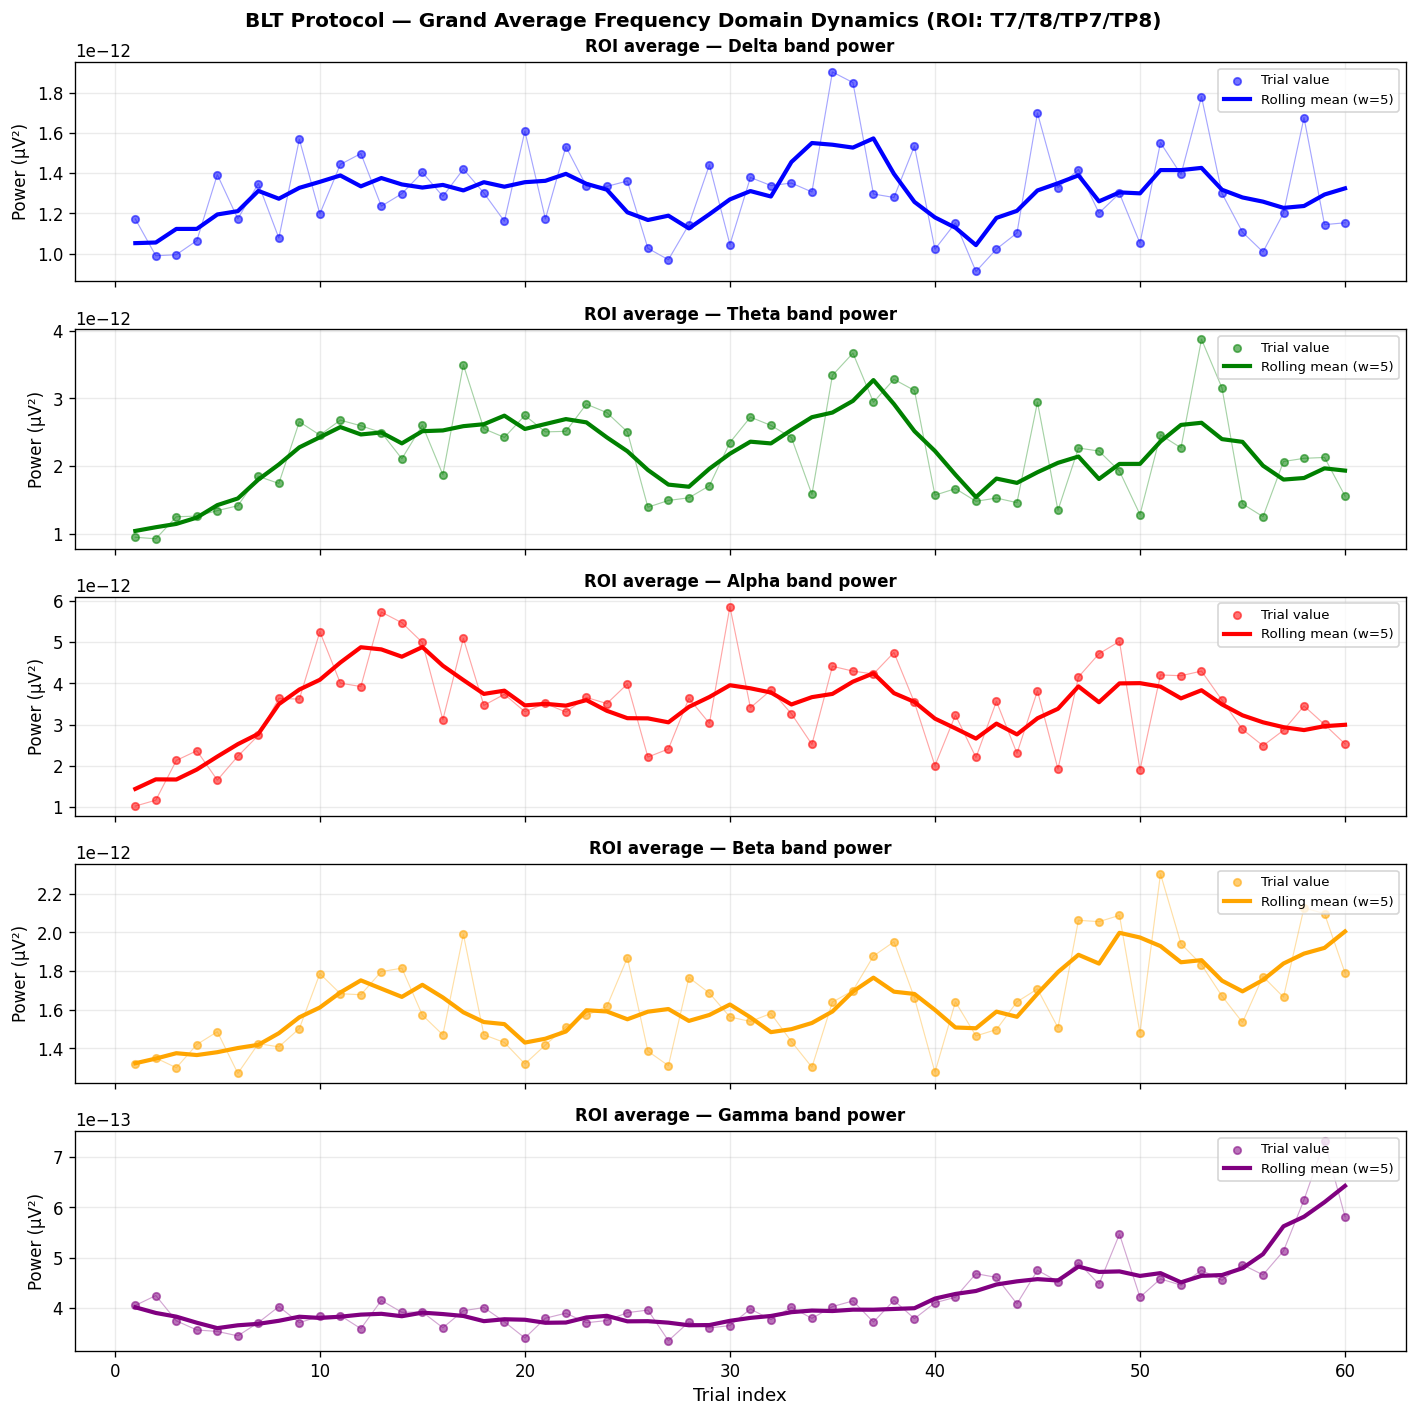

Figure saved: frequency_dynamics_BLT_grand_average.png
Analysis completed for subjects: [5, 10, 11, 12, 13]
Note: Grand average across all available BLT subject data files analyzed.


In [34]:
# Plot frequency power dynamics over trials for the grand average
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

grand_power = {}
for band in bands:
    band_trials = []
    for subject_id in SUBJECTS:
        if subject_id in all_power_pivots:
            power_pivot = all_power_pivots[subject_id]
            if band in power_pivot.columns:
                band_trials.append(power_pivot[band].reset_index(drop=True))

    if band_trials:
        grand_power[band] = pd.concat(band_trials, axis=1).mean(axis=1)

fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]
    if band in grand_power:
        values = grand_power[band].values
        trial_idx = np.arange(1, len(values) + 1)

        ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Trial value')
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

        s = pd.Series(values)
        rolling = s.rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
        ax.plot(trial_idx, rolling, color=color, linewidth=2.5, zorder=3,
                label=f'Rolling mean (w={ROLLING_WINDOW})')

    ax.set_ylabel('Power (µV²)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} band power', fontsize=10, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Trial index', fontsize=11)
fig.suptitle('BLT Protocol — Grand Average Frequency Domain Dynamics (ROI: T7/T8/TP7/TP8)',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('frequency_dynamics_BLT_grand_average.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: frequency_dynamics_BLT_grand_average.png")

print(f"Analysis completed for subjects: {sorted(all_power_pivots.keys())}")
print("Note: Grand average across all available BLT subject data files analyzed.")

In [35]:
# Compute relative power (percentage of total power) for frequency domain analysis
relative_power_dfs = {}
relative_power_pivots = {}

for subject_id in sorted(all_power_pivots.keys()):
    print(f"\n--- Computing Relative Power for Subject {subject_id} ---")

    power_pivot = all_power_pivots[subject_id]

    # Calculate total power across all bands for each trial
    total_power_per_trial = power_pivot.sum(axis=1)

    # Calculate relative power for each band
    relative_power = power_pivot.div(total_power_per_trial, axis=0) * 100

    # Store results
    relative_power_dfs[subject_id] = relative_power.reset_index()
    relative_power_pivots[subject_id] = relative_power

    print(f"Subject {subject_id}: relative power computed for {len(relative_power)} trials")

# Display relative power results
subject_id = sorted(relative_power_pivots.keys())[0]
print(f"\n--- Relative Power Results for Subject {subject_id} ---")
print("Relative power per band per trial (percentage of total power):")
relative_power_pivots[subject_id].head(10)


--- Computing Relative Power for Subject 5 ---
Subject 5: relative power computed for 60 trials

--- Computing Relative Power for Subject 10 ---
Subject 10: relative power computed for 60 trials

--- Computing Relative Power for Subject 11 ---
Subject 11: relative power computed for 60 trials

--- Computing Relative Power for Subject 12 ---
Subject 12: relative power computed for 60 trials

--- Computing Relative Power for Subject 13 ---
Subject 13: relative power computed for 60 trials

--- Relative Power Results for Subject 5 ---
Relative power per band per trial (percentage of total power):


band,above_gamma,alpha,below_delta,beta,delta,gamma,theta
trial,,,,,,,
0,NaN,20.122325,NaN,33.743177,22.075238,7.358911,16.700349
1,NaN,29.221960,NaN,34.999099,11.307240,9.941919,14.529782
2,NaN,26.271710,NaN,30.817830,18.568630,6.689447,17.652382
3,NaN,22.239505,NaN,30.669956,22.740445,6.072945,18.277150
4,NaN,19.869110,NaN,34.164211,20.973120,7.484381,17.509179
5,NaN,36.919620,NaN,22.727742,19.974997,5.576382,14.801259
6,NaN,20.052418,NaN,39.998710,13.430645,8.583405,17.934821
7,NaN,49.914421,NaN,19.346264,11.359558,4.263676,15.116081
8,NaN,30.449161,NaN,28.631167,16.529730,4.909048,19.480894


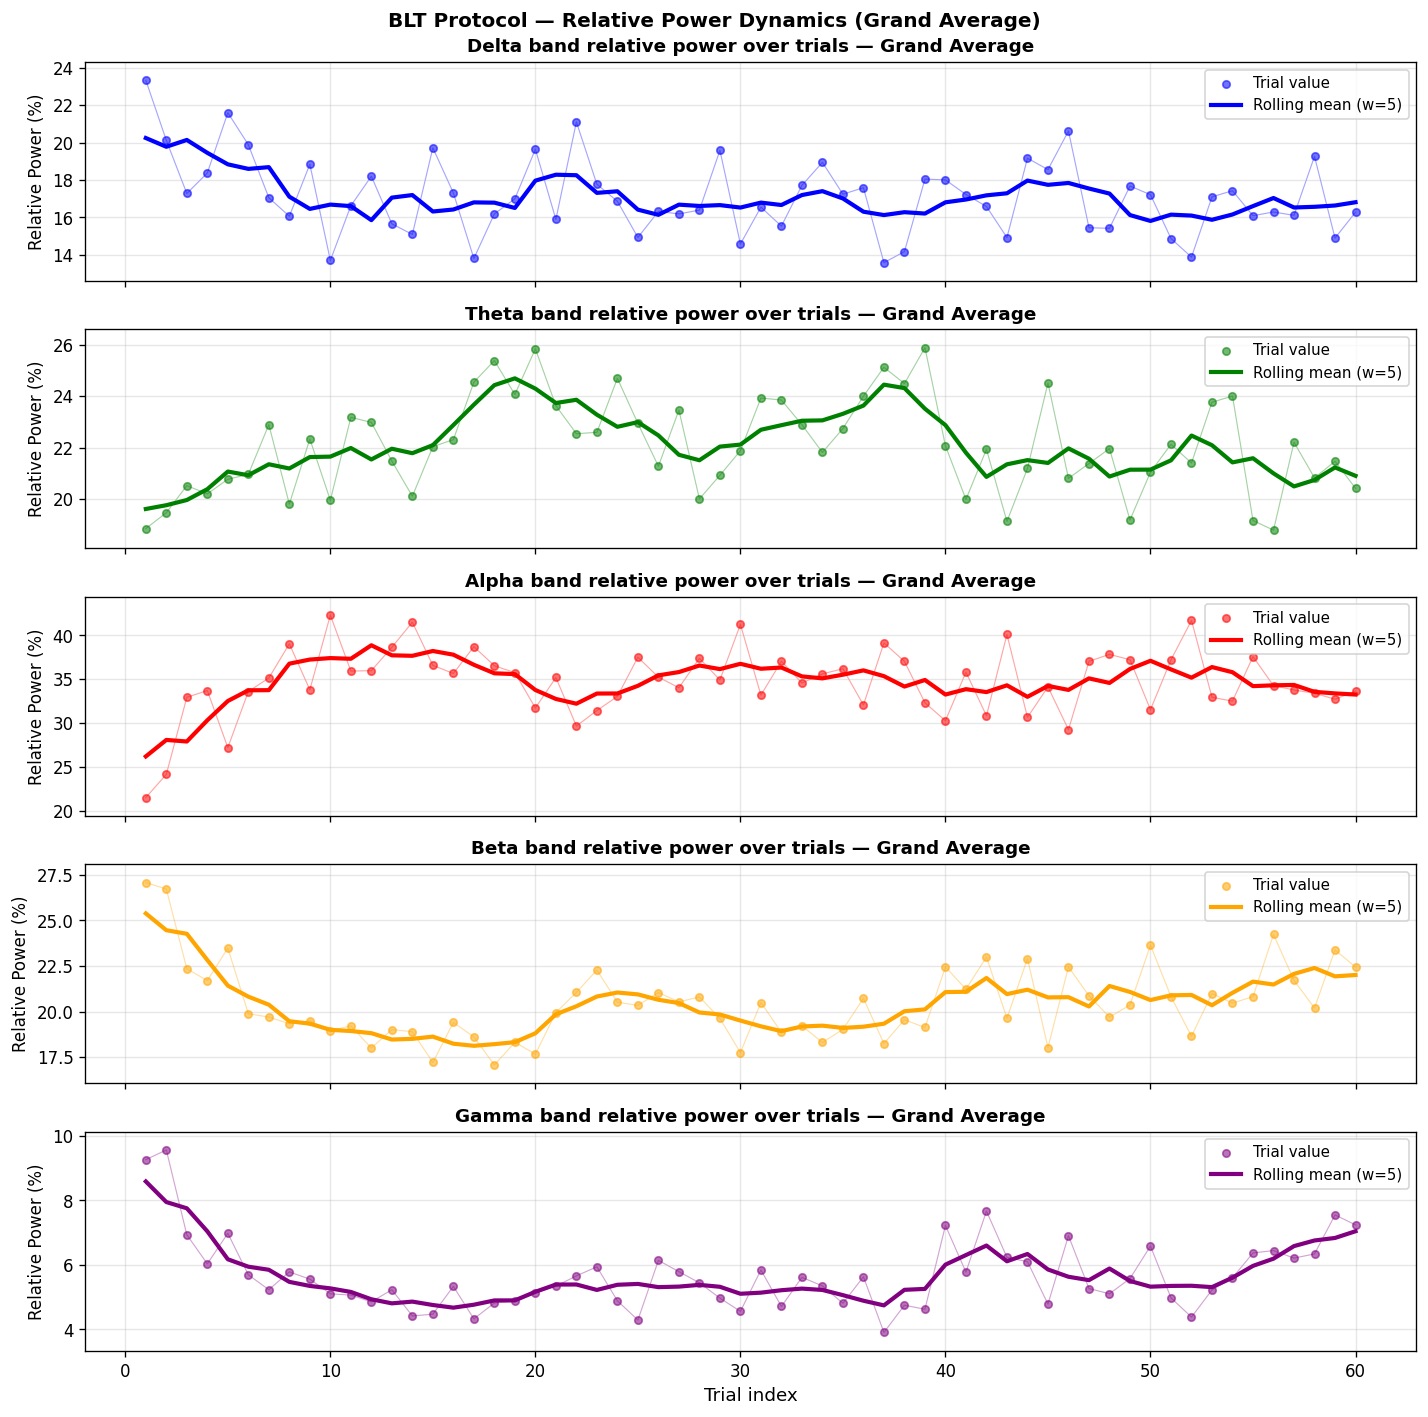

Figure saved: relative_power_dynamics_BLT_grand_average.png

Average relative power across all trials (Grand Average):
Delta: 17.1%
Theta: 22.1%
Alpha: 34.7%
Beta: 20.5%
Gamma: 5.7%

Analysis completed for subjects: [5, 10, 11, 12, 13]


In [36]:
# Plot relative power dynamics over trials (grand average)
grand_relative_power = {}
for band in bands:
    band_trials = []
    for subject_id in sorted(relative_power_pivots.keys()):
        relative_power_pivot = relative_power_pivots[subject_id]
        if band in relative_power_pivot.columns:
            band_trials.append(relative_power_pivot[band].reset_index(drop=True))

    if band_trials:
        grand_relative_power[band] = pd.concat(band_trials, axis=1).mean(axis=1)

fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]
    if band in grand_relative_power:
        values = grand_relative_power[band].values
        trial_idx = np.arange(1, len(values) + 1)

        ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Trial value')
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

        s = pd.Series(values)
        rolling = s.rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
        ax.plot(trial_idx, rolling, color=color, linewidth=2.5, zorder=3,
                label=f'Rolling mean (w={ROLLING_WINDOW})')

        min_val = grand_relative_power[band].min()
        max_val = grand_relative_power[band].max()
        pad = 0.1 * (max_val - min_val) if max_val > min_val else 1
        ax.set_ylim(min_val - pad, max_val + pad)

        ax.set_ylabel('Relative Power (%)', fontsize=10)
        ax.set_title(f'{band.capitalize()} band relative power over trials — Grand Average',
                     fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Trial index', fontsize=11)
fig.suptitle('BLT Protocol — Relative Power Dynamics (Grand Average)',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('relative_power_dynamics_BLT_grand_average.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: relative_power_dynamics_BLT_grand_average.png")

# Print average relative power across trials
print("\nAverage relative power across all trials (Grand Average):")
avg_relative_power = pd.DataFrame(grand_relative_power).mean()
for band in bands:
    if band in avg_relative_power.index:
        print(f"{band.capitalize()}: {avg_relative_power[band]:.1f}%")

print(f"\nAnalysis completed for subjects: {sorted(relative_power_pivots.keys())}")

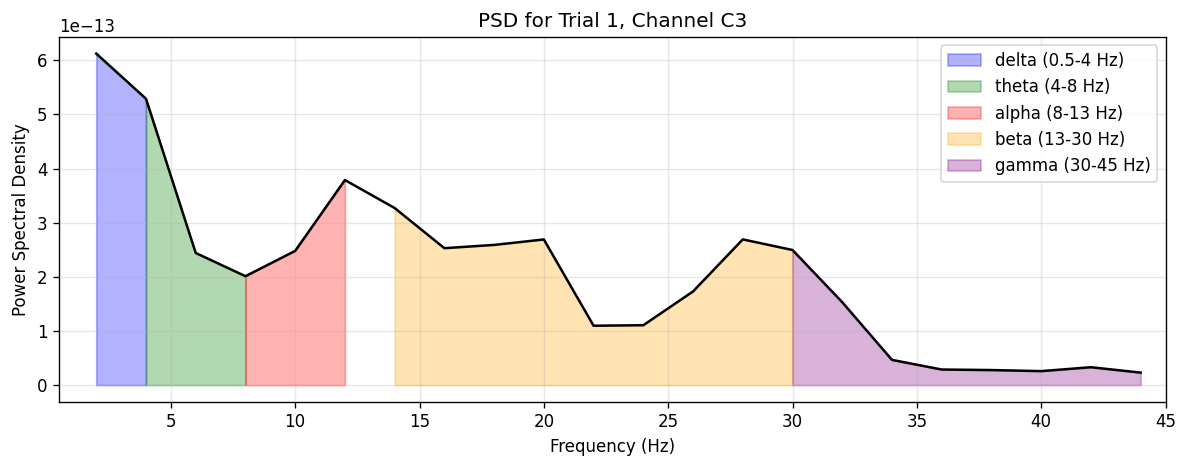

Figure saved: example_psd_BLT.png


In [18]:
# Example: Plot PSD for the first trial, first channel
trial = 0
channel = ch_names[0]
freqs, psd = psds_dict[(trial, channel)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(freqs, psd, color='black', linewidth=1.5)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power Spectral Density')
ax.set_title(f'PSD for Trial {trial+1}, Channel {channel}')
ax.grid(True, alpha=0.3)

# Shade frequency bands
band_colors = {'delta': 'blue', 'theta': 'green', 'alpha': 'red', 'beta': 'orange', 'gamma': 'purple'}
for band, (fmin, fmax) in FREQ_BANDS.items():
    if band in band_colors:
        mask = (freqs >= fmin) & (freqs <= fmax)
        ax.fill_between(freqs, 0, psd, where=mask, color=band_colors[band], alpha=0.3, label=f'{band} ({fmin}-{fmax} Hz)')

ax.legend()
ax.set_xlim(0.5, 45)
fig.tight_layout()
plt.savefig('example_psd_BLT.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: example_psd_BLT.png")

In [19]:
# Print PSD data for interpretation
trial = 0
channel = ch_names[0]
freqs, psd = psds_dict[(trial, channel)]

print(f"PSD for Trial {trial+1}, Channel {channel}")
print(f"Frequency range: {freqs[0]:.1f} - {freqs[-1]:.1f} Hz")
print(f"Number of frequency bins: {len(freqs)}")

# Find peak frequencies and powers in each band
from utils import FREQ_BANDS
for band, (fmin, fmax) in FREQ_BANDS.items():
    mask = (freqs >= fmin) & (freqs <= fmax)
    if mask.any():
        band_freqs = freqs[mask]
        band_psd = psd[mask]
        peak_idx = np.argmax(band_psd)
        peak_freq = band_freqs[peak_idx]
        peak_power = band_psd[peak_idx]
        mean_power = np.mean(band_psd)
        print(f"{band.capitalize()} band ({fmin}-{fmax} Hz): peak at {peak_freq:.1f} Hz ({peak_power:.2e} µV²), mean power {mean_power:.2e} µV²")

# Overall statistics
print(f"\nOverall PSD statistics:")
print(f"Total power (0.5-45 Hz): {np.sum(psd):.2e} µV²")
print(f"Mean power: {np.mean(psd):.2e} µV²")
print(f"Max power: {np.max(psd):.2e} µV² at {freqs[np.argmax(psd)]:.1f} Hz")

PSD for Trial 1, Channel C3
Frequency range: 2.0 - 44.0 Hz
Number of frequency bins: 22
Delta band (0.5-4 Hz): peak at 2.0 Hz (6.12e-13 µV²), mean power 5.71e-13 µV²
Theta band (4-8 Hz): peak at 4.0 Hz (5.29e-13 µV²), mean power 3.25e-13 µV²
Alpha band (8-13 Hz): peak at 12.0 Hz (3.79e-13 µV²), mean power 2.76e-13 µV²
Beta band (13-30 Hz): peak at 14.0 Hz (3.27e-13 µV²), mean power 2.24e-13 µV²
Gamma band (30-45 Hz): peak at 30.0 Hz (2.49e-13 µV²), mean power 7.34e-14 µV²

Overall PSD statistics:
Total power (0.5-45 Hz): 4.57e-12 µV²
Mean power: 2.08e-13 µV²
Max power: 6.12e-13 µV² at 2.0 Hz


In [20]:
# Count total trials for subject 5 across all conditions
import mne
from pathlib import Path

conditions = ['BLA', 'BLT', 'P1', 'P2', 'P3']
subject_id = 5

total_trials = 0
print("Trials per condition for Subject 5:")
print("-" * 40)

for condition in conditions:
    file_name = f"binepochs filtered ICArej {condition}AvgBOS{subject_id}.set"
    file_path = Path('dataset') / file_name

    if file_path.exists():
        epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)

        # Count meaningful trials (excluding "no auditory")
        # Based on the pattern in utils.py, even indices are auditory trials
        meaningful_trials = sum(1 for i in range(len(epochs)) if i % 2 == 0)
        print(f"{condition}: {meaningful_trials} trials")
        total_trials += meaningful_trials
    else:
        print(f"{condition}: file not found")

print("-" * 40)
print(f"Total trials for Subject 5: {total_trials}")

Trials per condition for Subject 5:
----------------------------------------
BLA: 60 trials
BLT: 60 trials


/var/folders/r2/rfwh_3n17gx6z6h72_b8ps8w0000gn/T/ipykernel_54650/3048869155.py:17: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)
/var/folders/r2/rfwh_3n17gx6z6h72_b8ps8w0000gn/T/ipykernel_54650/3048869155.py:17: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)
/var/folders/r2/rfwh_3n17gx6z6h72_b8ps8w0000gn/T/ipykernel_54650/3048869155.py:17: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


P1: 60 trials
P2: 60 trials
P3: 60 trials
----------------------------------------
Total trials for Subject 5: 300


/var/folders/r2/rfwh_3n17gx6z6h72_b8ps8w0000gn/T/ipykernel_54650/3048869155.py:17: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)
/var/folders/r2/rfwh_3n17gx6z6h72_b8ps8w0000gn/T/ipykernel_54650/3048869155.py:17: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


## 7. Time-Frequency Domain Analysis

Analyze the time-frequency dynamics of BLT trials to understand how oscillatory activity evolves over time within each trial. This complements the frequency-domain analysis by showing when specific frequency bands are active during the post-stimulus period.

Time-frequency analysis reveals:
- Event-related spectral perturbations (ERSP)
- When oscillatory activity increases/decreases relative to stimulus onset
- Dynamic changes in brain rhythms during learning

**Method**: Continuous Wavelet Transform using Morlet wavelets
**Frequency bands**: Same as frequency domain (delta, theta, alpha, beta, gamma)
**Subjects to analyze:** 5 (only available data)

In [38]:
# Import time-frequency functions
import mne
from mne.time_frequency import tfr_morlet

# Define parameters for time-frequency analysis
n_cycles = 2.0
freqs = np.logspace(np.log10(1), np.log10(45), 20)

print(f"Time-frequency analysis parameters:")
print(f"Frequencies: {freqs[0]:.1f} - {freqs[-1]:.1f} Hz ({len(freqs)} points)")
print(f"Wavelet cycles: {n_cycles}")

# Define only the BLT subjects that are working right now
SUBJECTS_TF = sorted(all_power_pivots.keys())

CONDITION = "BLT"
CHANNELS = "BLT"

print(f"Using subjects: {SUBJECTS_TF}")

Time-frequency analysis parameters:
Frequencies: 1.0 - 45.0 Hz (20 points)
Wavelet cycles: 2.0
Using subjects: [5, 10, 11, 12, 13]


In [39]:
# Compute time-frequency representations for each subject
tf_power_dfs = {}
tf_power_pivots = {}

for subject_id in SUBJECTS_TF:
    print(f"\n--- Computing Time-Frequency for Subject {subject_id} ---")

    # Load data
    epochs = load_eeg_data(CONDITION, subject_id, channels=CHANNELS)

    # Get baseline-corrected data
    data = epochs.get_data() * 1e6  # Convert to µV

    # Apply baseline correction
    baseline_mask = (epochs.times >= -0.200) & (epochs.times <= 0.000)
    baseline_mean = data[:, :, baseline_mask].mean(axis=-1, keepdims=True)
    data_bc = data - baseline_mean

    n_trials, n_channels, n_times = data_bc.shape
    ch_names = epochs.ch_names

    print(f"Data shape: {data_bc.shape} (trials × channels × times)")

    # Compute TFR for each channel
    tfr_data = []
    for ch_idx, ch in enumerate(ch_names):
        print(f"Computing TFR for channel {ch}...")

        # Compute TFR using Morlet wavelets
        tfr = tfr_morlet(
            epochs.copy().pick_channels([ch]),
            freqs,
            n_cycles=n_cycles,
            average=False,
            return_itc=False,
            verbose=False
        )

        # Get power data
        power = tfr.data ** 2  # (n_trials, n_channels, n_freqs, n_times)

        # Average across channels (here this is just the single picked channel)
        power_avg = power.mean(axis=1)  # (n_trials, n_freqs, n_times)
        tfr_data.append(power_avg)

    # Average across channels for ROI
    roi_power = np.mean(tfr_data, axis=0)  # (n_trials, n_freqs, n_times)

    # Use the actual TFR time axis
    times_ms = tfr.times * 1000

    # Extract power in frequency bands over time
    band_power_over_time = {}
    for band, (fmin, fmax) in FREQ_BANDS.items():
        freq_mask = (freqs >= fmin) & (freqs <= fmax)
        if freq_mask.any():
            band_power = roi_power[:, freq_mask, :].mean(axis=1)  # (n_trials, n_times)
            band_power_over_time[band] = band_power

    # Create DataFrame with time-frequency features
    tf_features = []
    for trial in range(n_trials):
        for time_idx, time_val in enumerate(times_ms):
            row = {'trial': trial + 1, 'time_ms': time_val}
            for band in FREQ_BANDS.keys():
                if band in band_power_over_time:
                    row[f'{band}_power'] = band_power_over_time[band][trial, time_idx]
            tf_features.append(row)

    tf_df = pd.DataFrame(tf_features)

    # Create pivot table: trials × time × bands
    tf_pivot = {}
    for band in FREQ_BANDS.keys():
        if f'{band}_power' in tf_df.columns:
            pivot = tf_df.pivot(index='trial', columns='time_ms', values=f'{band}_power')
            tf_pivot[band] = pivot

    # Store results
    tf_power_dfs[subject_id] = tf_df
    tf_power_pivots[subject_id] = tf_pivot

    print(f"Subject {subject_id}: {len(tf_df)} time-frequency measurements computed")

# Display results for first computed subject
subject_id = sorted(tf_power_dfs.keys())[0]
print(f"\n--- Time-Frequency Results for Subject {subject_id} ---")
print("Time-frequency DataFrame (first 10 rows):")
tf_power_dfs[subject_id].head(10)

print(f"\nPower over time for delta band (first 5 trials, first 10 time points):")
tf_power_pivots[subject_id]['delta'].iloc[:5, :10]


--- Computing Time-Frequency for Subject 5 ---
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Data shape: (60, 4, 1792) (trials × channels × times)
Computing TFR for channel C3...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


/Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/utils.py:128: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Computing TFR for channel C4...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Computing TFR for channel CP1...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Computing TFR for channel CP2...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Subject 5: 107520 time-frequency measurements computed

--- Computing Time-Frequency for Subject 10 ---
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Data shape: (60, 4, 1792) (trials × channels × times)
Computing TFR for channel C3...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy funct

/Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/utils.py:128: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Computing TFR for channel C4...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Computing TFR for channel CP1...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Computing TFR for channel CP2...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Subject 10: 107520 time-frequency measurements computed

--- Computing Time-Frequency for Subject 11 ---
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Data shape: (60, 4, 1792) (trials × channels × times)
Computing TFR for channel C3...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy func

...

/Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/utils.py:128: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Computing TFR for channel C4...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Computing TFR for channel CP1...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Computing TFR for channel CP2...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Subject 12: 107520 time-frequency measurements computed

--- Computing Time-Frequency for Subject 13 ---
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Data shape: (60, 4, 1792) (trials × channels × times)
Computing TFR for channel C3...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy func

/Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/utils.py:128: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Computing TFR for channel C4...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Computing TFR for channel CP1...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Computing TFR for channel CP2...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Subject 13: 107520 time-frequency measurements computed

--- Time-Frequency Results for Subject 5 ---
Time-frequency DataFrame (first 10 rows):

Power over time for delta band (first 5 trials, first 10 time points):


time_ms,-500.000000,-498.046875,-496.093750,-494.140625,-492.187500,-490.234375,-488.281250,-486.328125,-484.375000,-482.421875
trial,,,,,,,,,,
1,1.687135e-18,1.705267e-18,1.722954e-18,1.740167e-18,1.756877e-18,1.773056e-18,1.788680e-18,1.803721e-18,1.818157e-18,1.831964e-18
2,3.723897e-19,3.773205e-19,3.822632e-19,3.872192e-19,3.921896e-19,3.971759e-19,4.021789e-19,4.071997e-19,4.122389e-19,4.172970e-19
3,3.794529e-19,3.840828e-19,3.886916e-19,3.932826e-19,3.978593e-19,4.024253e-19,4.069843e-19,4.115397e-19,4.160953e-19,4.206543e-19
4,2.438972e-19,2.445345e-19,2.450858e-19,2.455539e-19,2.459420e-19,2.462534e-19,2.464919e-19,2.466613e-19,2.467659e-19,2.468101e-19
5,4.340749e-19,4.381754e-19,4.422023e-19,4.461581e-19,4.500461e-19,4.538697e-19,4.576331e-19,4.613405e-19,4.649967e-19,4.686066e-19


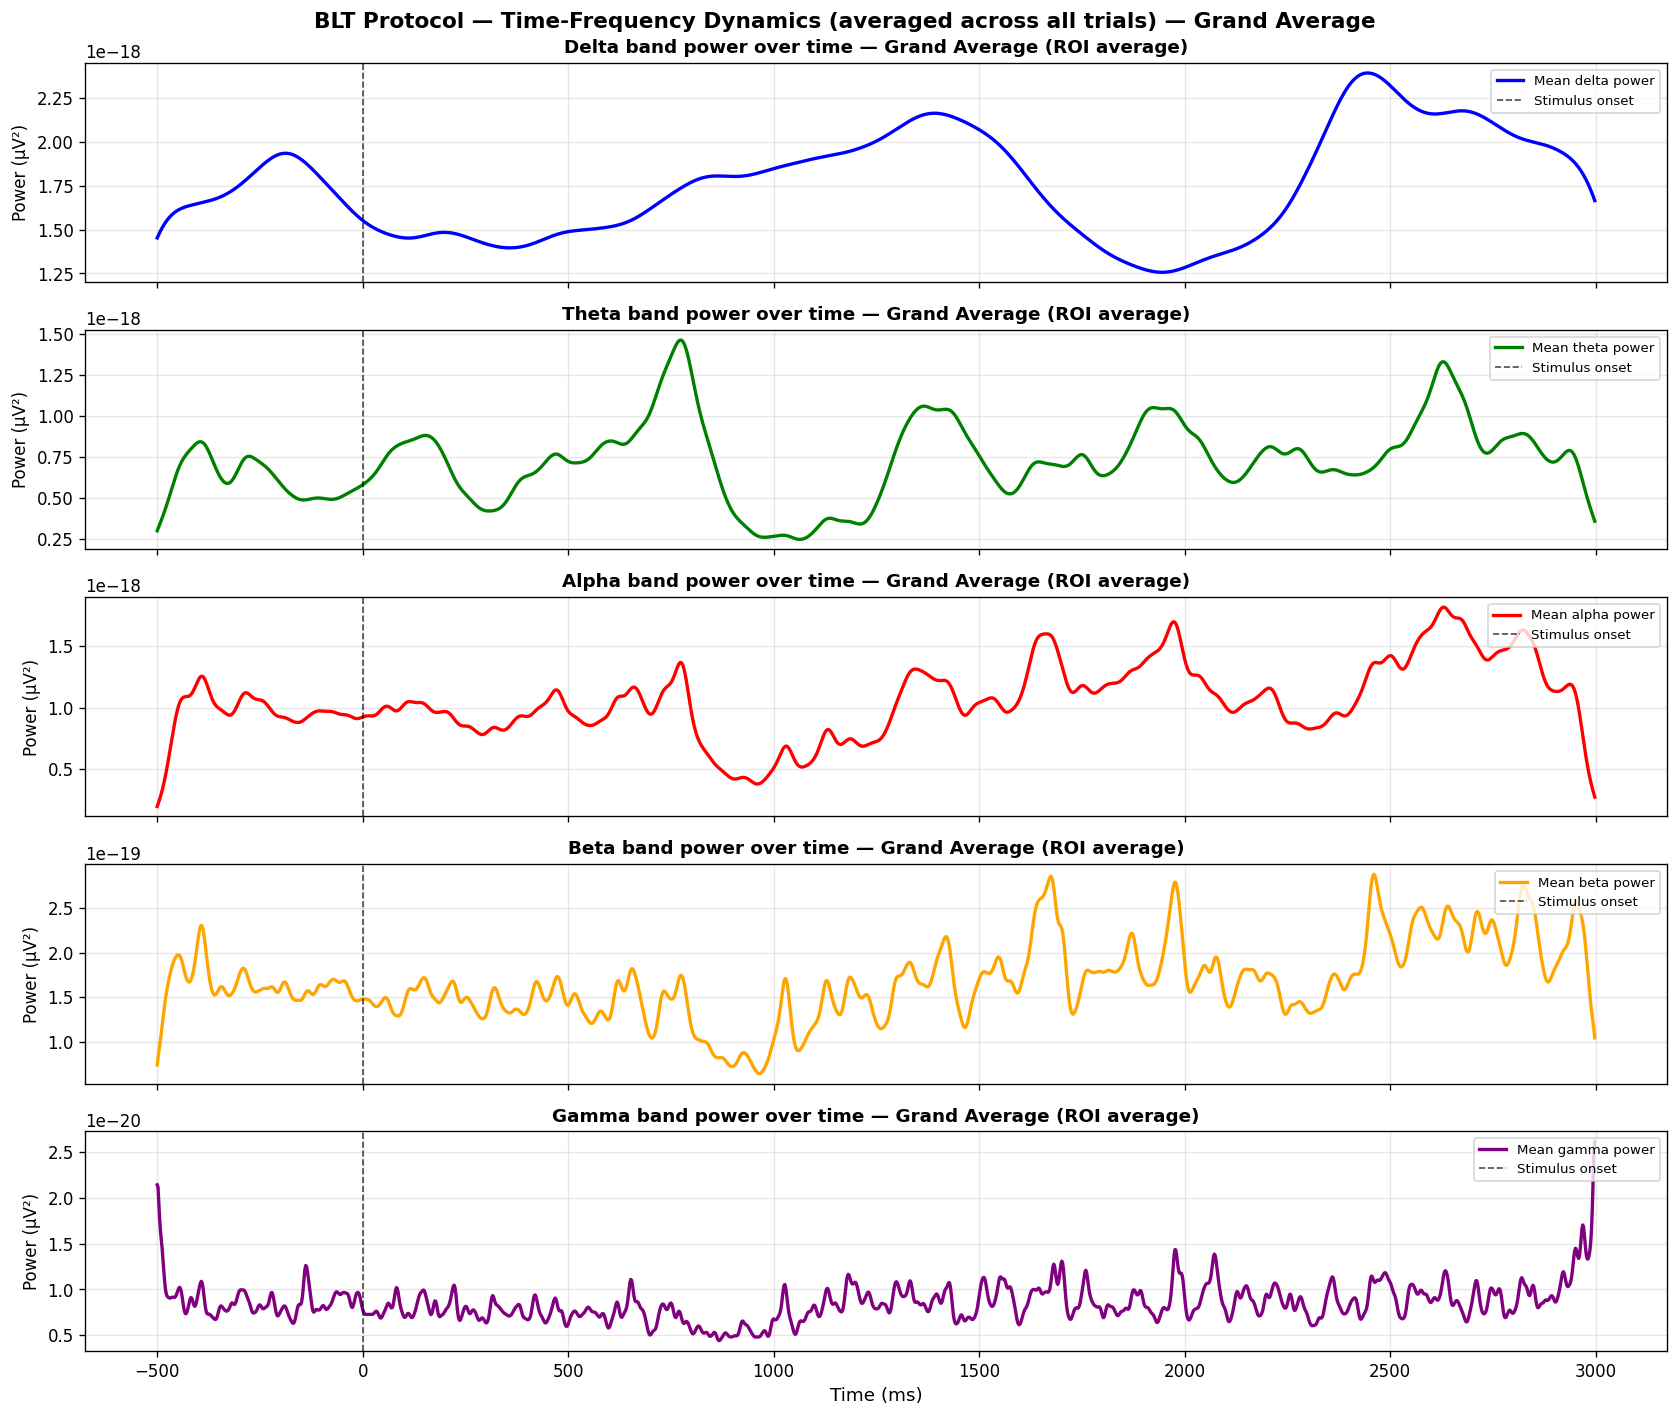

Figure saved: time_frequency_dynamics_BLT_grand_average.png
Analysis completed for subjects: [5, 10, 11, 12, 13]


In [40]:
# Plot time-frequency power dynamics over trials (grand average)
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

grand_tf_power = {}
for band in bands:
    band_subject_means = []
    for subject_id in sorted(tf_power_pivots.keys()):
        tf_pivot = tf_power_pivots[subject_id]
        if band in tf_pivot:
            pivot_data = tf_pivot[band]

            # mean over trials for this subject
            subject_mean = pivot_data.mean(axis=0)
            band_subject_means.append(subject_mean.reset_index(drop=True))

    if band_subject_means:
        grand_tf_power[band] = pd.concat(band_subject_means, axis=1)

# Get time points for plotting
first_subject = sorted(tf_power_pivots.keys())[0]
time_points = tf_power_pivots[first_subject]['delta'].columns.values  # time in ms

fig, axes = plt.subplots(len(bands), 1, figsize=(14, 12), sharex=True)

for i, band in enumerate(bands):
    ax = axes[i]
    if band in grand_tf_power:
        pivot_data = grand_tf_power[band]

        # Plot grand mean power over time across all subjects
        mean_power = pivot_data.mean(axis=1)

        ax.plot(time_points, mean_power, color=colors[i], linewidth=2, label=f'Mean {band} power')

        # Mark stimulus onset
        ax.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.7, label='Stimulus onset')

        ax.set_ylabel('Power (µV²)', fontsize=10)
        ax.set_title(f'{band.capitalize()} band power over time — Grand Average (ROI average)',
                     fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time (ms)', fontsize=11)
fig.suptitle('BLT Protocol — Time-Frequency Dynamics (averaged across all trials) — Grand Average',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('time_frequency_dynamics_BLT_grand_average.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: time_frequency_dynamics_BLT_grand_average.png")
print(f"Analysis completed for subjects: {sorted(tf_power_pivots.keys())}")

In [41]:
# Compute relative power for time-frequency domain analysis
tf_relative_power_dfs = {}
tf_relative_power_pivots = {}

for subject_id in sorted(tf_power_pivots.keys()):
    print(f"\n--- Computing Relative Time-Frequency Power for Subject {subject_id} ---")

    tf_pivot = tf_power_pivots[subject_id]

    # For each time point, calculate relative power across bands
    relative_tf_pivot = {}
    for band in FREQ_BANDS.keys():
        if band in tf_pivot:
            band_pivot = tf_pivot[band]

            # Calculate total power across all bands at each time point for each trial
            time_points = band_pivot.columns
            total_power_at_time = pd.DataFrame(index=band_pivot.index, columns=time_points)

            for time_point in time_points:
                total_at_time = 0
                for b in FREQ_BANDS.keys():
                    if b in tf_pivot:
                        total_at_time += tf_pivot[b][time_point]
                total_power_at_time[time_point] = total_at_time

            # Calculate relative power: band_power / total_power * 100
            relative_power = band_pivot.div(total_power_at_time, axis=0) * 100
            relative_tf_pivot[band] = relative_power

    # Store results
    tf_relative_power_dfs[subject_id] = relative_tf_pivot
    tf_relative_power_pivots[subject_id] = relative_tf_pivot

    print(f"Subject {subject_id}: relative time-frequency power computed")

# Display results for first available subject
subject_id = sorted(tf_relative_power_pivots.keys())[0]
print(f"\n--- Relative Time-Frequency Results for Subject {subject_id} ---")
print("Available bands:", list(tf_relative_power_pivots[subject_id].keys()))
print("Relative power for delta band (first 5 trials, first 5 time points):")
if 'delta' in tf_relative_power_pivots[subject_id]:
    print(tf_relative_power_pivots[subject_id]['delta'].iloc[:5, :5])
else:
    print("Delta band not found")


--- Computing Relative Time-Frequency Power for Subject 5 ---
Subject 5: relative time-frequency power computed

--- Computing Relative Time-Frequency Power for Subject 10 ---
Subject 10: relative time-frequency power computed

--- Computing Relative Time-Frequency Power for Subject 11 ---
Subject 11: relative time-frequency power computed

--- Computing Relative Time-Frequency Power for Subject 12 ---
Subject 12: relative time-frequency power computed

--- Computing Relative Time-Frequency Power for Subject 13 ---
Subject 13: relative time-frequency power computed

--- Relative Time-Frequency Results for Subject 5 ---
Available bands: ['delta', 'theta', 'alpha', 'beta', 'gamma', 'above_gamma']
Relative power for delta band (first 5 trials, first 5 time points):
time_ms  -500.000000  -498.046875  -496.093750  -494.140625  -492.187500
trial                                                                   
1          93.085802    92.595623    92.089709    91.567122    91.025739
2      

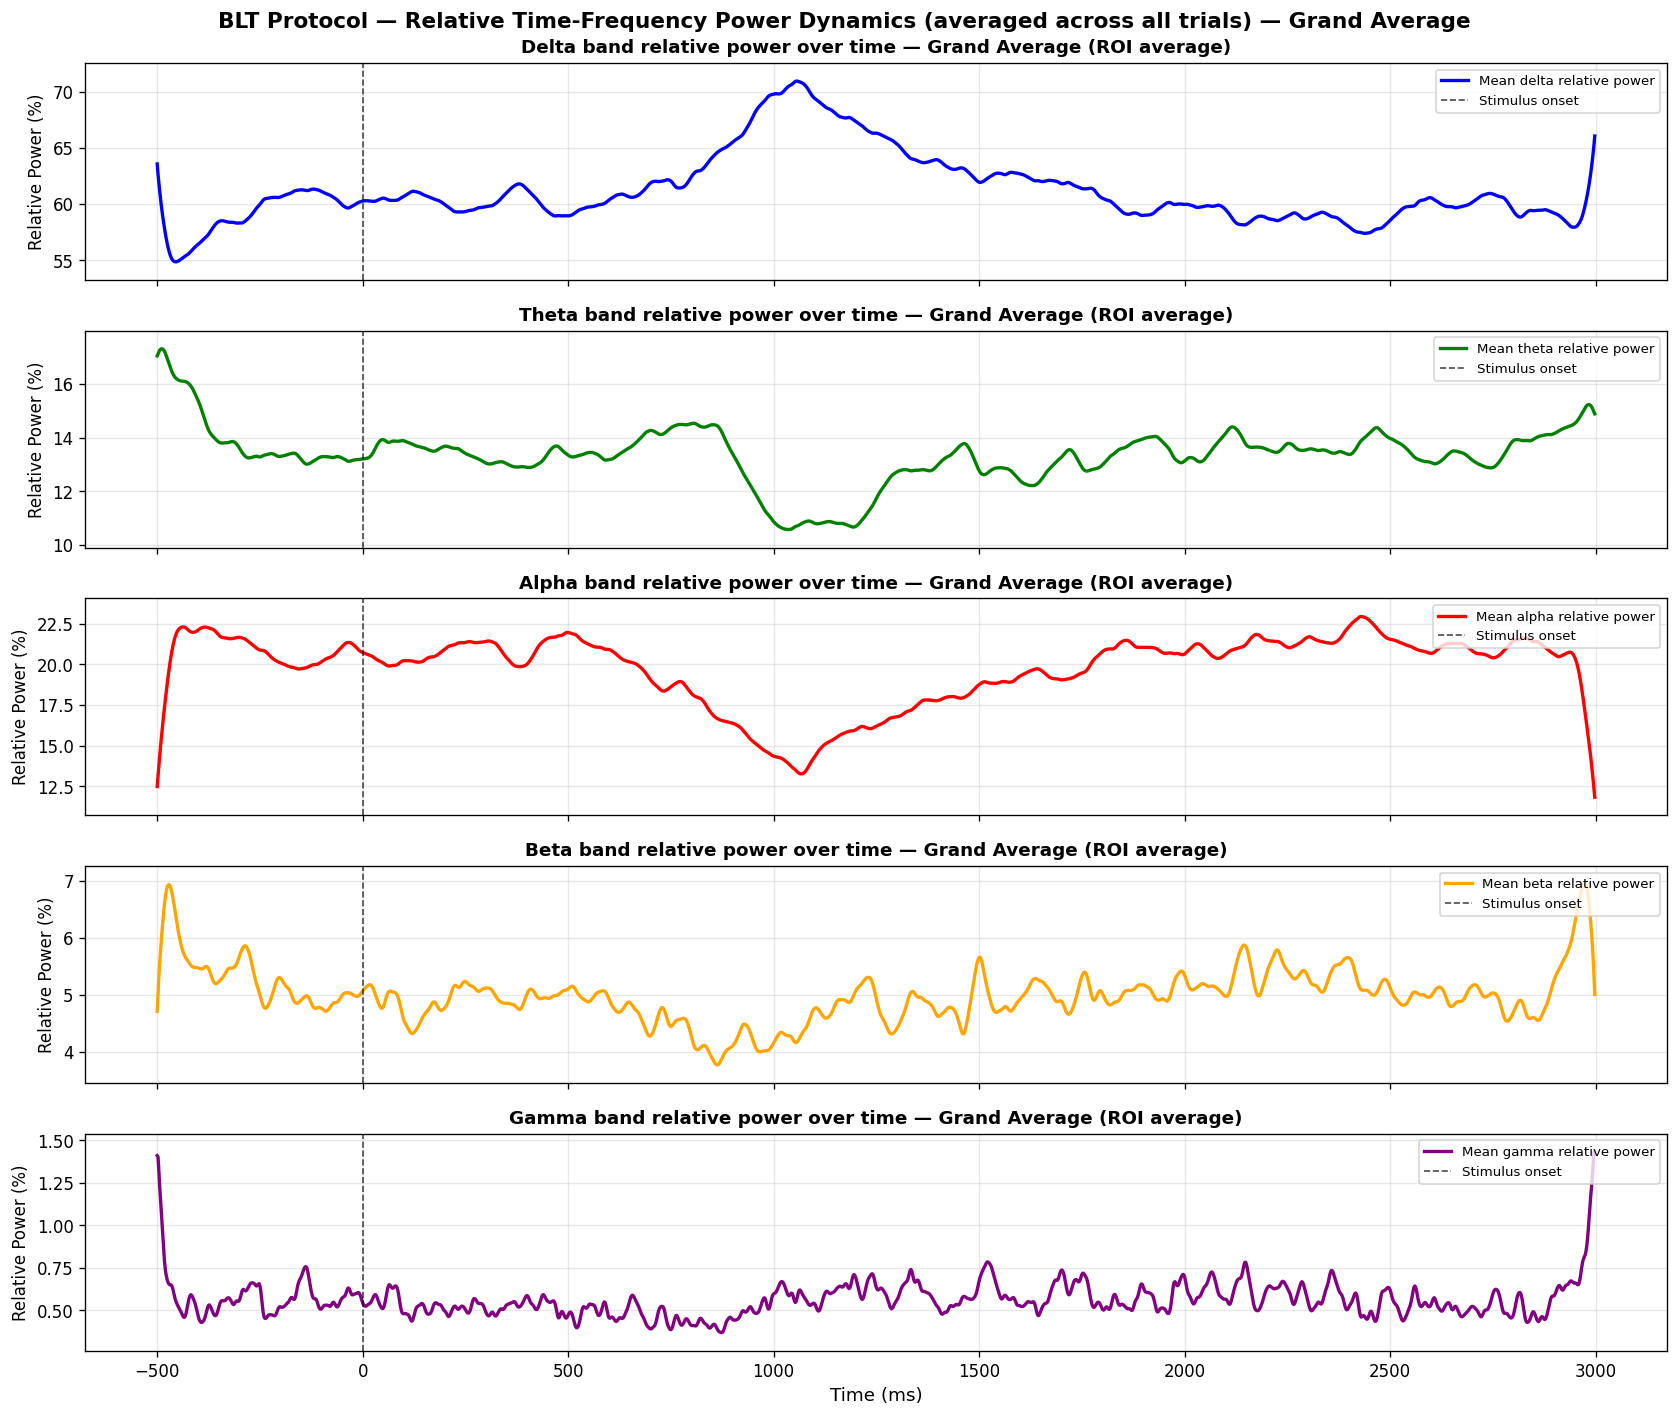

Figure saved: relative_time_frequency_dynamics_BLT_grand_average.png

Average relative power across time (Grand Average):
Delta: 61.2%
Theta: 13.3%
Alpha: 19.8%
Beta: 5.0%
Gamma: 0.6%

Analysis completed for subjects: [5, 10, 11, 12, 13]


In [42]:
# Plot relative time-frequency power dynamics over trials (grand average)
grand_tf_relative_power = {}
for band in bands:
    band_subject_means = []
    for subject_id in sorted(tf_relative_power_pivots.keys()):
        tf_relative_pivot = tf_relative_power_pivots[subject_id]
        if band in tf_relative_pivot:
            pivot_data = tf_relative_pivot[band]

            # mean over trials for this subject
            subject_mean = pivot_data.mean(axis=0)
            band_subject_means.append(subject_mean.reset_index(drop=True))

    if band_subject_means:
        grand_tf_relative_power[band] = pd.concat(band_subject_means, axis=1)

# Get time points for plotting
first_subject = sorted(tf_relative_power_pivots.keys())[0]
time_points = tf_relative_power_pivots[first_subject]['delta'].columns.values

fig, axes = plt.subplots(len(bands), 1, figsize=(14, 12), sharex=True)

for i, band in enumerate(bands):
    ax = axes[i]
    if band in grand_tf_relative_power:
        pivot_data = grand_tf_relative_power[band]

        # Plot grand mean relative power over time across all subjects
        mean_power = pivot_data.mean(axis=1)

        ax.plot(time_points, mean_power, color=colors[i], linewidth=2, label=f'Mean {band} relative power')

        # Mark stimulus onset
        ax.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.7, label='Stimulus onset')

        # Set y-axis to fit the data properly
        min_val = mean_power.min()
        max_val = mean_power.max()
        pad = 0.1 * (max_val - min_val) if max_val > min_val else 1
        ax.set_ylim(min_val - pad, max_val + pad)

        ax.set_ylabel('Relative Power (%)', fontsize=10)
        ax.set_title(f'{band.capitalize()} band relative power over time — Grand Average (ROI average)',
                     fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time (ms)', fontsize=11)
fig.suptitle('BLT Protocol — Relative Time-Frequency Power Dynamics (averaged across all trials) — Grand Average',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('relative_time_frequency_dynamics_BLT_grand_average.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: relative_time_frequency_dynamics_BLT_grand_average.png")

# Print average relative power across time for each band
print("\nAverage relative power across time (Grand Average):")
for band in bands:
    if band in grand_tf_relative_power:
        avg_relative_power = grand_tf_relative_power[band].mean().mean()
        print(f"{band.capitalize()}: {avg_relative_power:.1f}%")

print(f"\nAnalysis completed for subjects: {sorted(tf_relative_power_pivots.keys())}")

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


/Users/zach/Documents/Physics of Cognition/Physics-of-Cognition_Learning/utils.py:128: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


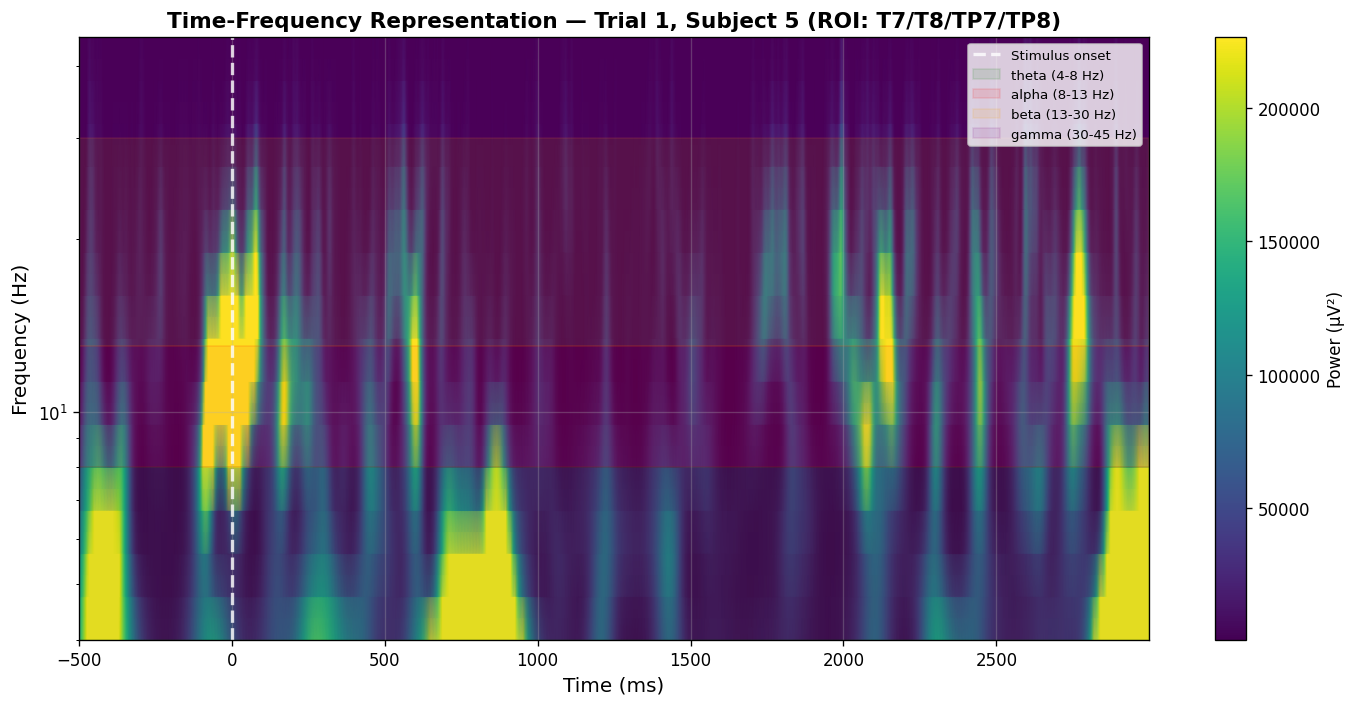

Figure saved: example_time_frequency_BLT.png

Time-frequency statistics for Trial 1:
Delta band: mean power 8.79e+04 µV², max power 1.70e+05 µV²
Theta band: mean power 5.74e+04 µV², max power 3.57e+05 µV²
Alpha band: mean power 1.72e+05 µV², max power 1.12e+06 µV²
Beta band: mean power 6.46e+04 µV², max power 8.36e+05 µV²
Gamma band: mean power 4.21e+03 µV², max power 2.99e+04 µV²


In [26]:
# Example: Plot time-frequency representation for the first trial, ROI average
trial = 0
subject_id = 5

# Load data for single trial TFR
epochs = load_eeg_data(CONDITION, subject_id, channels=CHANNELS)
data = epochs.get_data() * 1e6

# Baseline correction for all trials
baseline_mask = (epochs.times >= -0.200) & (epochs.times <= 0.000)
baseline_mean = data[:, :, baseline_mask].mean(axis=-1, keepdims=True)
data_bc = data - baseline_mean

# Create single-trial epochs properly
info = epochs.info
single_trial_data = data_bc[trial:trial+1]  # Shape: (1, n_channels, n_times)
epochs_trial = mne.EpochsArray(single_trial_data, info, tmin=epochs.tmin, verbose=False)

# Use higher frequency range to avoid wavelet length issues
freqs_example = np.logspace(np.log10(4), np.log10(45), 15)  # 4-45 Hz

tfr = tfr_morlet(epochs_trial, freqs_example, n_cycles=n_cycles,
                average=False, return_itc=False, verbose=False)

# Average across channels
power = (tfr.data ** 2).mean(axis=1).squeeze()  # (n_freqs, n_times)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

# Create time-frequency plot
times_ms = tfr.times * 1000
mesh = ax.pcolormesh(times_ms, freqs_example, power,
                    shading='gouraud', cmap='viridis',
                    vmin=np.percentile(power, 5), vmax=np.percentile(power, 95))

ax.axvline(0, color='white', linestyle='--', linewidth=2, alpha=0.8, label='Stimulus onset')
ax.set_xlabel('Time (ms)', fontsize=12)
ax.set_ylabel('Frequency (Hz)', fontsize=12)
ax.set_title(f'Time-Frequency Representation — Trial {trial+1}, Subject {subject_id} (ROI: T7/T8/TP7/TP8)',
             fontsize=13, fontweight='bold')
ax.set_yscale('log')

# Add colorbar
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Power (µV²)', fontsize=10)

# Shade frequency bands (adjusted for higher freq range)
band_colors = {'theta': 'green', 'alpha': 'red', 'beta': 'orange', 'gamma': 'purple'}
for band, (fmin, fmax) in FREQ_BANDS.items():
    if band in band_colors and fmax >= 4:  # Only show bands that overlap with our freq range
        plot_fmin = max(fmin, 4)
        plot_fmax = min(fmax, 45)
        ax.axhspan(plot_fmin, plot_fmax, alpha=0.1, color=band_colors[band],
                  label=f'{band} ({fmin}-{fmax} Hz)')

ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig('example_time_frequency_BLT.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: example_time_frequency_BLT.png")

# Print some statistics
print(f"\nTime-frequency statistics for Trial {trial+1}:")
for band, (fmin, fmax) in FREQ_BANDS.items():
    if fmax >= 4:  # Only for bands in our frequency range
        freq_mask = (freqs_example >= max(fmin, 4)) & (freqs_example <= min(fmax, 45))
        time_mask = (times_ms >= 0) & (times_ms <= 400)  # Post-stimulus window
        if freq_mask.any():
            band_power = power[freq_mask, :][:, time_mask]
            mean_power = np.mean(band_power)
            max_power = np.max(band_power)
            print(f"{band.capitalize()} band: mean power {mean_power:.2e} µV², max power {max_power:.2e} µV²")

## Summary

| Step | Details |
|---|---|
| Protocol | BLT (Baseline Tactile) |
| Subject | 5 |
| ROI | T7, T8, TP7, TP8 (temporal/temporo-parietal) |
| Trials (tactile) | 60 |
| Baseline window | −200 ms to 0 ms, mean subtraction |
| Time-frequency method | Continuous Wavelet Transform (Morlet wavelets) |
| Frequencies | 1-45 Hz (log-spaced, 20 points) |
| Wavelet cycles | 2.0 |
| Frequency bands | Delta (0.5-4 Hz), Theta (4-8 Hz), Alpha (8-13 Hz), Beta (13-30 Hz), Gamma (30-45 Hz) |

**Key differences from frequency domain analysis:**
- **Frequency domain**: Shows average power in each frequency band across the entire trial
- **Time-frequency domain**: Shows how power in each frequency band changes over time within each trial

**Relative power analysis:**
- **Frequency domain**: Relative power shows the percentage contribution of each band to total power across trials
- **Time-frequency domain**: Relative power shows the percentage contribution of each band at each time point
- **Advantages**: Normalizes for individual differences in overall power levels, focuses on relative contributions

**Next steps:**
- Analyze other protocols (BLA, P1, P2, P3) for subject 5
- Compare relative power dynamics across protocols
- Look for event-related spectral perturbations (ERSP) that indicate learning-related changes